# Group 10 - Data Science for Marketing group project


**Group members:**
* Beatriz Santos - 20221937
* Bernardo Teixeira - 20250831
* Manuel Freudenthal - 20250835
* Maria Inês Castro - 20221842

#0. Connecting to Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

path = '/content/drive/My Drive/Colab Notebooks/DS4M/Data/'

Mounted at /content/drive


#1. Import

Import the libraries

In [2]:
!pip install joypy

In [3]:
# Library to detect language in text
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 53.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=9964aa8289780e31ac2e1f8099cb0ff50369fe6a39801948aa4b00880292b5a4
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [4]:
!pip install squarify

In [5]:
# Packages
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import joypy
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import re
import nltk
from nltk.corpus import stopwords
from langdetect import detect, DetectorFactory
from sklearn.metrics import pairwise_distances
import squarify
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import networkx as nx
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import apriori
from nltk.sentiment import SentimentIntensityAnalyzer
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import chi2_contingency
from scipy.stats import spearmanr

# Safely ignore / suppress warning for clean code outputs
import warnings
warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module="jupyter_client"
)

Import datasets

In [6]:
# Import the 3 datasets
attractions_df = pd.read_csv(path + "attractions_list.csv", sep=",")
metadata_df = pd.read_csv(path + "attractions_data_metadata.csv", sep=",")
reviews_df = pd.read_csv(path + "attraction_data_reviews.csv", sep=",")


#2. Business Understanding

Context and Role of LTA

* Lisbon Tourism Authority (LTA) promotes Lisbon as a high-quality, competitive, and sustainable tourist destination. Online platforms such as Tripadvisor play a key role in shaping visitor expectations and reflecting real experiences, with reviews capturing perceptions about satisfaction, value for money, crowding, accessibility, and service quality.

Business Problem
* Tripadvisor reviews are rich in insight but largely unstructured, making them difficult to translate into actionable marketing and management decisions. This project supports LTA by transforming review data into structured indicators that inform marketing, operations, and visitor experience management, particularly ahead of high-demand tourism seasons.

Goal 1: Sustainable Tourism Development
* Sustained tourism growth requires maintaining high experience quality alongside increasing visitor numbers. KPIs such as the Overall Satisfaction Score and the Experience Quality Index enable LTA to monitor satisfaction over time and assess whether tourism development remains balanced and sustainable.

Goal 2 and 3: Leisure and Business Tourism Promotion
* The promotion of Lisbon as a leisure and business destination depends on identifying experiences that deliver high satisfaction and operational reliability. Indicators such as Topic Sentiment Scores, Accessibility Scores, and the Crowding Pressure Index help evaluate emotional engagement, accessibility, and capacity-related issues across visit types.

Goal 4: Visitor Information and Decision Support
* Visitor feedback on signage, transport, and staff helpfulness reflects the effectiveness of tourist information and support services. Translating these insights into KPIs supports evidence-based decision-making, helps prioritize high-impact interventions for the next season, and strengthens Lisbon’s long-term attractiveness as a destination.

#3. Data Understanding

## 3.0. Merge Datasets

Standardize the primary keys

In [7]:
# All primary keys will be named "tripadvisor_id"
attractions_df.rename(columns={"tripadvisor_id": "tripadvisor_id"}, inplace=True)
metadata_df.rename(columns={"tripadvisorId": "tripadvisor_id"}, inplace=True)
reviews_df.rename(columns={"tripadvisorId": "tripadvisor_id"}, inplace=True)

Check primary key's uniqueness

In [8]:
# Attraction's datasets primary keys should be unique
print("Attractions unique:", attractions_df["tripadvisor_id"].is_unique)
print("Metadata unique:", metadata_df["tripadvisor_id"].is_unique)

# Review dataset's primary keys should not be unique, as mutliple review are made for the same attractions
print("Reviews unique:", reviews_df["tripadvisor_id"].is_unique)

Attractions unique: True
Metadata unique: True
Reviews unique: False


1st Merge - Reviews and Metadata

In [9]:
# Left join on tripadvisor_id
merged_df = reviews_df.merge(
    metadata_df,
    on="tripadvisor_id",
    how="left",
    # add a suffix to diferentiate variables with the same name form different datasets
    suffixes=("", "_attraction")
)

2nd Merge - Previous + Attractions

In [10]:
# Left join on tripadvisor_id
merged_df = merged_df.merge(
    attractions_df,
    on="tripadvisor_id",
    how="left",
    # add a suffix to diferentiate variables with the same name form different datasets
    suffixes=("", "_list")
)

Check for conformance

In [11]:
# Number of rows from final merge should equal number of reviews
print("Reviews rows:", reviews_df.shape[0])
print("Merged rows:", merged_df.shape[0])

# Check for failed joins
print("Missing attraction names (%):",
      merged_df["name"].isna().mean() * 100)

Reviews rows: 143656
Merged rows: 143656
Missing attraction names (%): 0.0


No errors in merging, rename dataset

In [12]:
data_df = merged_df

##3.1. Data Overview

Data Summary

In [13]:
# Make an overall exploration of the dataset

print("Overview information of the dataset:")
print("\n\nShape:\n")
print(data_df.shape)
print("\n\nData Types:\n")
print(data_df.dtypes)
print("\n\nMissing Values:\n")
print(data_df.isnull().sum())
print("\n\nPercentage of Missing Values:\n")
print(data_df.isna().sum()/data_df.shape[0]*100)
print("\n\nMetric data descriptive statistics:\n")
print(data_df.describe().T)
print("\n\nCategorical data information:\n")
print(data_df.describe(include = ['O']))

Overview information of the dataset:


Shape:

(143656, 29)


Data Types:

title                                   object
text                                    object
rating                                   int64
reviewer                                object
visitMonth                              object
country                                 object
visitType                               object
contributions                          float64
likesNumber                              int64
replyText                               object
replyDate                               object
reviewDate                              object
name                                    object
tripadvisor_id                           int64
dateFirstCollection                     object
name_attraction                         object
location                                object
latitude                               float64
longitude                              float64
dateFirstCollection_attraction  

Features without value

In [14]:
# remove features without value
columns_to_drop = ['dateFirstCollection', 'location', 'latitude', 'longitude', 'url']
data_df = data_df.drop(columns=[col for col in columns_to_drop if col in data_df.columns])

* 'dateFirstCollection' only tells the date that the data was collected from Tripadvisor. This isn't relevant to our analysis;
* 'location', 'latitude' and 'longitude' have 87% of missing values. It's not viable to keep these variables;
* 'url' will serve no purpose in analytical methods.

Duplicate features resulting from merge

In [15]:
# remove duplicate features that resulted from merging
columns_to_drop = ['name_attraction', 'dateFirstCollection_attraction', 'name_list', 'url_list']
data_df = data_df.drop(columns=[col for col in columns_to_drop if col in data_df.columns])

* "..._attraction": variables duplicated from attractions
metadata dataset to prevent errors when merging
* "..._list": variables duplicated from attractions list dataset to prevent errors when merging

Reassess Data Summary

In [16]:
# Make an overall exploration of the dataset

print("Overview information of the dataset:")
print("\n\nShape:\n")
print(data_df.shape)
print("\n\nData Types:\n")
print(data_df.dtypes)
print("\n\nMissing Values:\n")
print(data_df.isnull().sum())
print("\n\nPercentage of Missing Values:\n")
print(data_df.isna().sum()/data_df.shape[0]*100)
print("\n\nMetric data descriptive statistics:\n")
print(data_df.describe().T)
print("\n\nCategorical data information:\n")
print(data_df.describe(include = ['O']))

Overview information of the dataset:


Shape:

(143656, 20)


Data Types:

title                                   object
text                                    object
rating                                   int64
reviewer                                object
visitMonth                              object
country                                 object
visitType                               object
contributions                          float64
likesNumber                              int64
replyText                               object
replyDate                               object
reviewDate                              object
name                                    object
tripadvisor_id                           int64
ratingGlobal                           float64
reviewCount                            float64
attractionCategory                      object
rankingPositionAttractionCategory      float64
totalRankingUnitsAttractionCategory    float64
num_reviews                     

## 3.2. Data Understanding


In this section, we explore the dataset in greater depth. The objective is to better understand the structure, completeness, and underlying patterns in the data, as well as to identify potential limitations and opportunities for subsequent analysis.

To support this section's goal, the variables were organized into thematic categories reflecting their role in the analysis.

* **Review & Experience Variables** capture visitor evaluations through ratings, review text characteristics, and management replies to assess perceived experience quality.

* **Visitor Profile Variables** describe visit context (visit type and origin), mainly supporting segmentation while highlighting data quality constraints.

* **Temporal Variables** record when reviews occur, enabling the analysis of coverage, seasonality, and temporal stability in satisfaction.

* **Attraction & Supply-Side Variables** describe attraction performance and visibility, including category, review concentration, global ratings, and ranking position.

* **Engagement & Interaction Variables** measure user and management activity (likes, contributions, replies) to assess engagement intensity and reputation management.



---



###3.2.1. Review & Experience Variables


**a)** How are ratings distributed?

In [17]:
data_df['rating'].value_counts(normalize=True).sort_index() * 100
data_df['rating'].describe()

,rating
count,143656.000000
mean,4.767354
std,0.773809
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


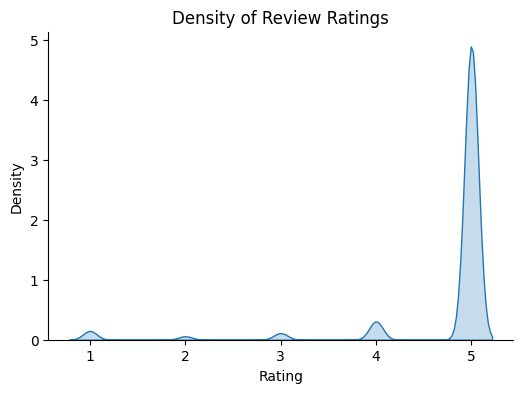

In [18]:
# Density chart
plt.figure(figsize=(6,4))
sns.kdeplot(data_df['rating'], fill=True)
plt.title("Density of Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Density")
sns.despine()
plt.show()


Conclusions:


*    Ratings are heavily concentrated at 5 stars, with at least 75% of observations receiving the maximum score.
*   The distribution is strongly left-skewed, meaning low ratings are rare.
* The average rating is very high (≈ 4.77), indicating overall strong positive evaluations.
* Low variability (std ≈ 0.77) shows little differentiation between ratings.



**b)** Are longer reviews associated with lower ratings?

In [19]:
data_df['text_length'] = data_df['text'].str.len()
data_df.groupby('rating')['text_length'].mean()


,text_length
rating,
1,538.908636
2,486.589488
3,406.733472
4,313.494586
5,266.263386


Conclusions:
* There is a clear negative association between review length and rating: as ratings increase, the average length of reviews consistently decreases.
* Lower-rated reviews (1–2 stars) are substantially longer, suggesting that dissatisfied users tend to provide more detailed explanations of their experiences.
* Higher-rated reviews (4–5 stars) are much shorter, indicating that satisfied users often express their opinion with brief, less elaborate comments.
* This pattern suggests that longer reviews are generally associated with lower ratings, likely because negative experiences require more justification or description.

**c)** How frequently do attractions reply to reviews?

In [20]:
reply_rate = data_df['replyText'].notna().mean() * 100
print(f"Attractions reply to {reply_rate:.1f}% of the reviews.")

Attractions reply to 34.3% of the reviews.


Conclusions:
* 34.3% indicates a moderate level of responsiveness.
* Replies are likely prioritized for specific cases (e.g., negative feedback or detailed reviews), rather than applied uniformly.

**d)** How quick do attractions reply to reviews?

In [21]:
# Convert to datetime (temporary, safe even if already datetime)
review_dt = pd.to_datetime(data_df['reviewDate'], errors='coerce')
reply_dt = pd.to_datetime(data_df['replyDate'], errors='coerce')

# Compute response time in days (only where a reply exists)
response_time_days = (reply_dt - review_dt).dt.days

# Keep only valid replies
response_time_days = response_time_days.dropna()

# Quick checks
response_time_days.describe()

,0
count,49335.000000
mean,20.279132
std,60.608006
min,0.000000
25%,1.000000
50%,3.000000
75%,10.000000
max,807.000000


Conclusions:
*   Attractions take, on average, 20 days to reply to reviews, which is considered too long to reply.



**e)** Are attractions more likely to reply to certain reviews?

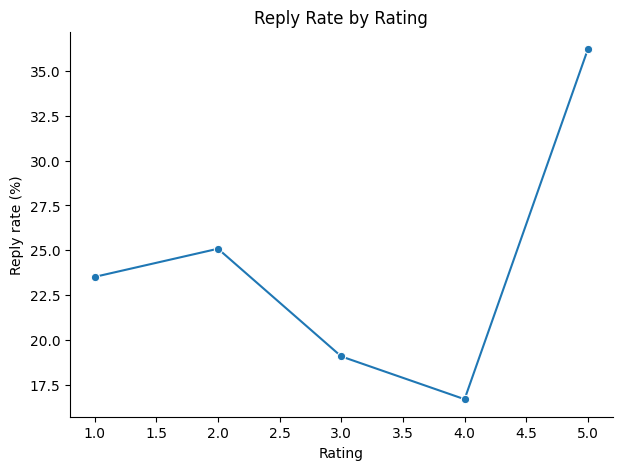

In [22]:
# Line plot with percentages

#create variable to know if there is a reply
data_df['has_reply'] = data_df['replyText'].notna()

reply_by_rating = (
    data_df.groupby('rating')['has_reply']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(7,5))
sns.lineplot(data=reply_by_rating, x='rating', y='has_reply', marker='o')
plt.ylabel('Reply rate (%)')
plt.xlabel('Rating')
plt.title('Reply Rate by Rating')
sns.despine()
plt.show()


Conclusions:
* Overall, attractions tend to respond most to the most extreme reviews, especially highly positive ones.

###3.2.2 Language Variables

**a)** In which languages are the reviews?

In [23]:
# Lightweight language detection, due to large size of the dataset

DetectorFactory.seed = 0  # reproducibility

def detect_language_light(text, max_chars=300):
    """
    Fast heuristic:
    - Assume English by default
    - Only detect language if non‑ASCII characters appear
    - Limit text length to reduce computation
    """
    if pd.isna(text):
        return np.nan

    text = str(text)

    # If the text is ascii only, we're almost certainly English in this dataset
    if text.isascii():
        return 'en'

    try:
        return detect(text[:max_chars])
    except:
        return np.nan

# Apply
data_df['detected_language'] = data_df['text'].apply(detect_language_light)

# Quick check
data_df['detected_language'].value_counts(normalize=True).head(10) * 100


,proportion
detected_language,
en,93.246319
es,2.428039
pt,1.580175
it,1.099857
fr,1.031638
de,0.311858
el,0.043855
nl,0.039678
pl,0.034109


Conclusions:
* 93% of reviews are in english, indicating very low linguistic diversity in the dataset. This means that differences in ratings and engagement are unlikely to be driven by language effects, therefore, we will remove this variable.


In [24]:
# Drop variable detected_language
data_df = data_df.drop(columns=['detected_language'])



---



###3.2.3. Visitor Profile Variables

**a)** How are visit types distributed?

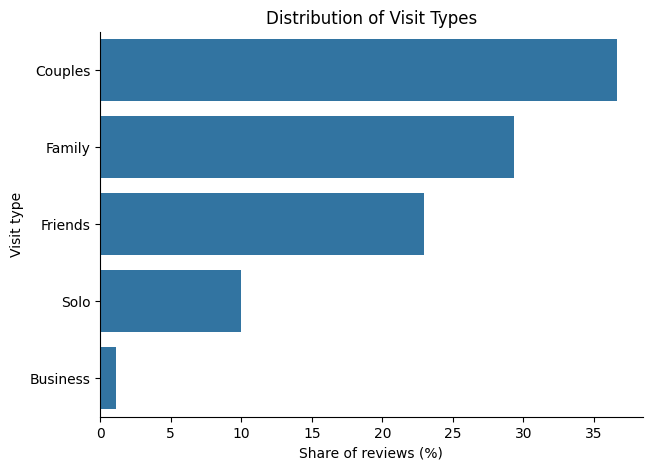

In [25]:
# Bar plot for shares

visit_pct = (
    data_df['visitType']
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)
visit_pct.columns = ['visitType', 'percentage']

plt.figure(figsize=(7,5))
sns.barplot(data=visit_pct, x='percentage', y='visitType')
plt.xlabel('Share of reviews (%)')
plt.ylabel('Visit type')
plt.title('Distribution of Visit Types')
sns.despine()
plt.show()


Conclusions:
* Most visits are social in nature, with Couples (36.6%), Families (29.3%), and Friends (23.0%) accounting for nearly 90% of all visits.
* Couples are the most common visit type, representing over one-third of the sample.
* Solo visits are relatively uncommon (≈ 10%), indicating that attractions are less frequently visited alone.
* Business-related visits are marginal (≈ 1%), suggesting that these attractions are primarily leisure-oriented.

**b)** Does satisfaction vary by visit type?

In [26]:
data_df.groupby('visitType')['rating'].mean()


,rating
visitType,
Business,4.720804
Couples,4.730661
Family,4.776482
Friends,4.788925
Solo,4.728243


Conclusions:
* Satisfaction levels are consistently high across all visit types, with average ratings close to 4.7–4.8.
* Differences between visit types are minimal, indicating broadly similar satisfaction regardless of how visitors attend.

**c)** How geographicaly distributed are the reviewers?

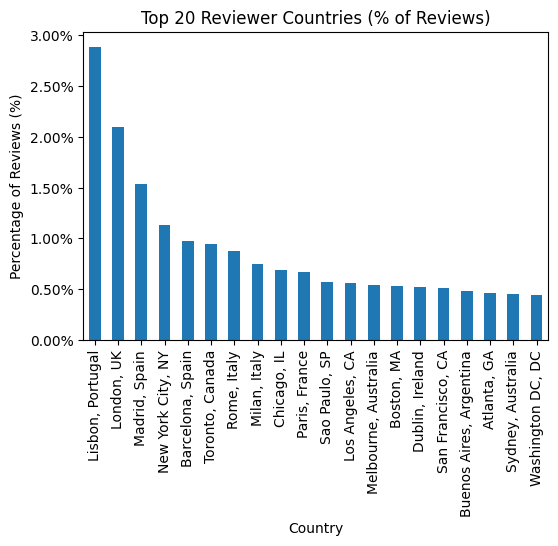

In [27]:
# Calculate percentage distribution (excluding missing values)
country_percent = (
    data_df["country"].value_counts(normalize=True).head(20) * 100
)

plt.figure(figsize=(6,4))
country_percent.plot(kind="bar")
plt.title("Top 20 Reviewer Countries (% of Reviews)")
plt.xlabel("Country")
plt.ylabel("Percentage of Reviews (%)")
plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter())
plt.show()


Conclusions:
* The dataset is highly lacking, with 60.7% of reviewers not having a country associated.
* Another problem arrised: the variable "country" states the city, creating different values for the same countries (different cities).
* For USA reviewers the country is not even specified, only the state.





---



###3.2.4. Temporal Variables

**a)** What is the temporal coverage of the data?

In [28]:
data_df['reviewDate'] = pd.to_datetime(data_df['reviewDate'])
data_df['reviewDate'].min(), data_df['reviewDate'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-07-31 00:00:00'))

Conclusions:
* The dataset covers a period of approximately 2.5 years, from January 2023 to July 2025.

**b)** How are reviews distributed over time?

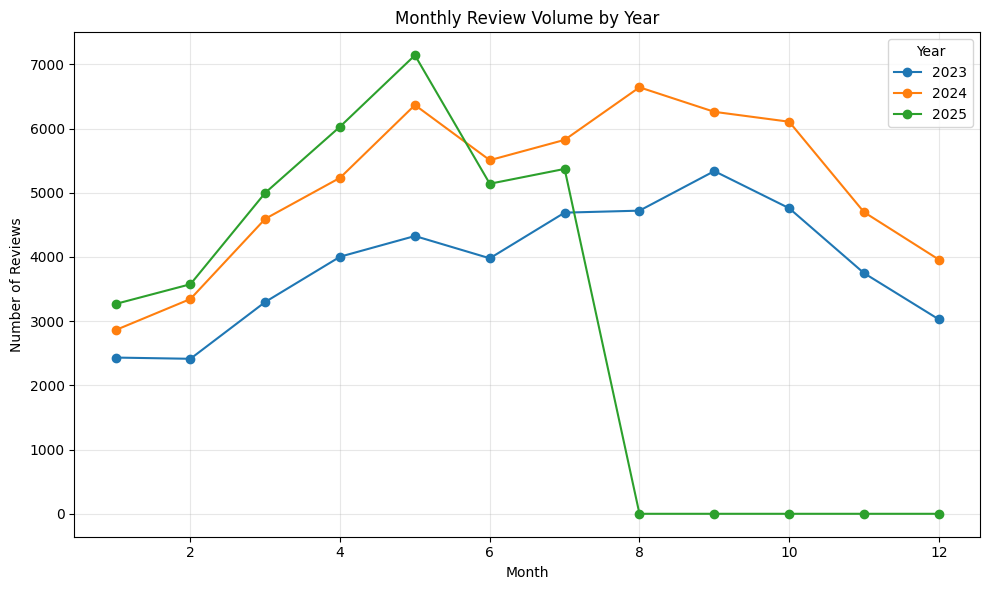

In [29]:
# Ensure reviewDate is datetime
data_df["reviewDate"] = pd.to_datetime(data_df["reviewDate"], errors="coerce")

# Create year x month table
reviews_year_month = pd.crosstab(
    data_df["reviewDate"].dt.month,
    data_df["reviewDate"].dt.year
).sort_index()

# Plot separate lines (one per year)
plt.figure(figsize=(10,6))

for year in reviews_year_month.columns:
    plt.plot(
        reviews_year_month.index,
        reviews_year_month[year],
        marker="o",
        label=str(year)
    )

plt.title("Monthly Review Volume by Year")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.legend(title="Year")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Conclusions:
* Number of Reviews is unevenly distributed across the year, showing clear seasonality.
* Activity increases from early spring until early autumn, when tourism demand is highest.
* Review volume declines during winter, with the lowest activity observed in January.

**c)** Does satisfaction change throughout the year?

In [30]:
data_df.groupby(data_df['reviewDate'].dt.month)['rating'].mean()

,rating
reviewDate,
1,4.764307
2,4.779837
3,4.789792
4,4.756206
5,4.765940
6,4.760016
7,4.767691
8,4.753410
9,4.773390


Conclusions:
* Overall, visitor satisfaction is stable over time, suggesting a consistently positive experience regardless of season.
* Suggests that the reviews are not prone to change with the effects of seasonality.
* As the reviews revealed to be left-skewed the values throughout the year would always be tending to 5.



---



###3.2.5. Attraction & Supply-Side Variables

**a)** How concentrated are reviews across attractions?

In [31]:
data_df['name'].value_counts().head(10)
data_df['name'].value_counts(normalize=True).head(10) * 100


,proportion
name,
Take Lisboa,24.090188
Eating Europe Food Tours Lisbon,3.564070
Inside Lisbon Tours,3.339923
I Took a Tuk Tuk,2.748232
World Experience - Lisboa,2.157933
Eco Tuk Tours Lisboa,1.944924
Game Over Escape Rooms LISBOA,1.668569
ColourTrip Lisbon,1.438158
Secret Food Tours Lisbon,1.314947


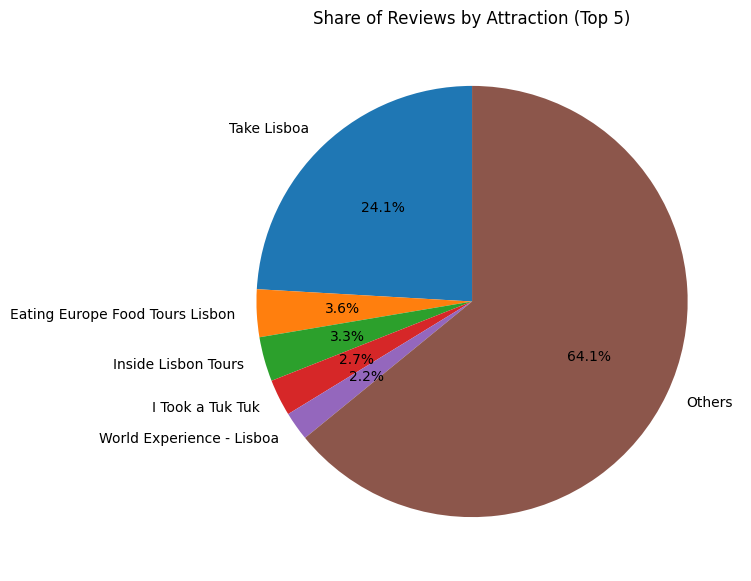

In [32]:
# Get top 5 attractions by number of reviews
top_n = 5
top_attractions = data_df['name'].value_counts(normalize=True).head(top_n) * 100

# Add "Others"
others = 100 - top_attractions.sum()
top_attractions['Others'] = others

plt.figure(figsize=(7,7))
plt.pie(
    top_attractions.values,
    labels=top_attractions.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Share of Reviews by Attraction (Top 5)')
plt.show()

Conclusions:
* Reviews are highly concentrated among a small number of attractions, indicating an uneven distribution.
* One attraction (“Take Lisboa”) alone accounts for about 24% of all reviews, showing a strong dominance.

**b)** Do global attraction ratings align with individual reviews?

In [33]:
data_df[['rating', 'ratingGlobal']].corr()


,rating,ratingGlobal
rating,1.000000,0.660128
ratingGlobal,0.660128,1.000000


Conclusions:
* Overall, global ratings provide a reasonably reliable summary of individual satisfaction, as evidenced by the strong positive correlation with individual review ratings. However, since the relationship is not perfect, global ratings do not fully capture the variability in individual experiences and should therefore be complemented with review-level analysis.

**c)** Does Lisbon have top 10% attractions in their respective categories?

In [34]:
# Select only attraction-level information and remove duplicates
attraction_level_df = (
    data_df[
        [
            "tripadvisor_id",
            "attractionCategory",
            "rankingPositionAttractionCategory",
            "totalRankingUnitsAttractionCategory"
        ]
    ]
    .dropna()
    .drop_duplicates(subset="tripadvisor_id")
)

# Determine whether each attraction is in the top 10% of its category
attraction_level_df["top_10_percent"] = (
    attraction_level_df["rankingPositionAttractionCategory"]
    <= 0.10 * attraction_level_df["totalRankingUnitsAttractionCategory"]
)

# Count how many attractions per category are in the top 10%
top_10_percent_table = (
    attraction_level_df
    .groupby("attractionCategory")["top_10_percent"]
    .sum()
    .astype(int)
    .reset_index(name="Top 10% Attractions")
)

# Total attractions per category
total_attractions = (
    attraction_level_df
    .groupby("attractionCategory")
    .size()
    .reset_index(name="Total Attractions")
)

# Merge totals with top 10% counts
top_10_percent_table = top_10_percent_table.merge(
    total_attractions,
    on="attractionCategory"
)

# Percentage of category in top 10%
top_10_percent_table["% of Category in Top 10%"] = (
    top_10_percent_table["Top 10% Attractions"]
    / top_10_percent_table["Total Attractions"]
    * 100
).round(2)

top_10_percent_table.sort_values(
    by="Top 10% Attractions",
    ascending=False
)


top_10_percent_table

,attractionCategory,Top 10% Attractions,Total Attractions,% of Category in Top 10%
0,amusement parks,0,1,0.00
1,boat tours & water sports,35,150,23.33
2,classes & workshops,16,45,35.56
3,events,0,1,0.00
4,food & drink,29,113,25.66
5,fun & games,11,46,23.91
6,museums,0,5,0.00
7,nature & parks,1,3,33.33
8,nightlife,30,138,21.74
9,outdoor activities,26,80,32.50


Conclusions:
* There are some areas with really low values but they present strange total attracions values.
* Overall the number of attractions that each category has in the top 10% represents around 30% of the number of attraction in the respective category



---



###3.2.6. Engagement & Interaction Variables

**a)** How proactive are reviewers?

In [35]:
data_df['contributions'].describe()

,contributions
count,143135.000000
mean,419.456478
std,5830.198492
min,0.000000
25%,1.000000
50%,3.000000
75%,12.000000
max,189877.000000


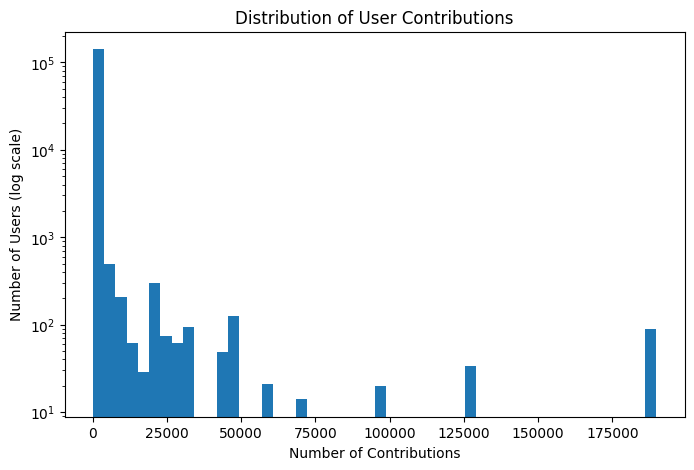

In [36]:
# Distribution of User Contributions
plt.figure(figsize=(8,5))
plt.hist(data_df['contributions'], bins=50, log=True)
plt.xlabel('Number of Contributions')
plt.ylabel('Number of Users (log scale)')
plt.title('Distribution of User Contributions')
plt.show()

Conclusion
* The distribution of contributions is strongly right-skewed, meaning a minority of users account for a disproportionate share of activity.
* Most reviewers are not proactive, with a median of only 3 contributions and 75% having 12 or fewer.

**b)** How much engagement do reviews receive?

In [37]:
data_df['likesNumber'].describe()

,likesNumber
count,143656.000000
mean,0.173442
std,1.614340
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,105.000000


In [38]:
data_df['likesNumber'].describe()
data_df['likesNumber'].value_counts().head(10)


,count
likesNumber,
0,127896
1,13976
2,1185
3,187
4,74
5,63
6,34
9,19
7,15


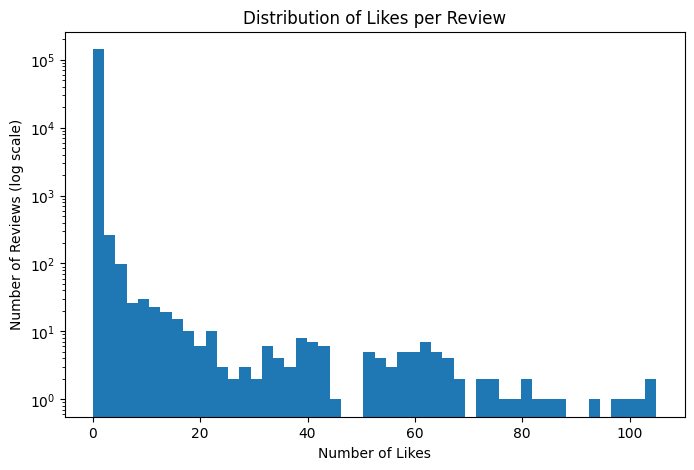

In [39]:
plt.figure(figsize=(8,5))
plt.hist(data_df['likesNumber'], bins=50, log=True)
plt.xlabel('Number of Likes')
plt.ylabel('Number of Reviews (log scale)')
plt.title('Distribution of Likes per Review')
plt.show()

Conclusions:
* Engagement is generally very low, with the vast majority of reviews receiving no likes at all.
* Most reviews have zero likes, indicating that user interaction with reviews is limited.
* When engagement occurs, it is minimal, typically 1–2 likes.
* High engagement is extremely rare, as only a very small fraction of reviews receive more than 5 likes.
* The distribution is highly right-skewed, with a long tail of a few highly liked reviews.


**c)** Is review engagement related to rating?

In [40]:
data_df.groupby('rating')['likesNumber'].mean()


,likesNumber
rating,
1,0.368615
2,0.303393
3,0.299758
4,0.607152
5,0.136225


Conclusions:
* Review engagement varies with rating, but not in a linear way:
    * 4-star reviews receive the highest average number of likes, suggesting they are perceived as more helpful or balanced.
    * 1-star reviews receive more engagement than 5-star reviews, likely because negative experiences attract attention or discussion.
    * 5-star reviews receive the lowest engagement on average, possibly due to being shorter and less informative.
* Overall, moderate or critical reviews tend to generate more engagement than extremely positive ones.




---



###3.2.7. Key Takeaways for Data Preparation

**Review & Experience Variables**
* Ratings are strongly skewed toward 5 stars, with review text length and engagement providing complementary signals that should be engineered rather than relying on averages alone.

**Visitor Profile Variables**
* Visit type is informative for segmentation but not strongly differentiating satisfaction, while geographic data is too incomplete and inconsistent to be reliably used without substantial cleaning.

**Temporal Variables**
* Review activity shows clear seasonality over a 2.5 year period, but satisfaction remains stable across time, making temporal features more relevant for volume analysis than experience quality.

**Attraction & Supply‑Side Variables**
* Reviews and visibility are highly concentrated amongst a small subset of attractions, and ranking variables enables meaningful relative performance benchmarking across categories.

**Engagement & Interaction Variables**
* User activity, likes, and replies are extremely right‑skewed and selective, indicating that binary or transformed engagement features are more appropriate than raw counts.

##3.3. Exploratory Data Analysis

The dataset was separated into numerical, categorical, temporal, text and identifier subsets to enable more appropriate and focused analyses for each variable type

In [41]:
numerical_variables = ['rating', 'contributions', 'likesNumber',
                       'num_reviews', 'ratingGlobal', 'reviewCount',
                       'rankingPositionAttractionCategory', 'totalRankingUnitsAttractionCategory',
                       'has_reply', 'text_length']

categorical_variables = ['visitType', 'country', 'attractionCategory']


temporal_variables = ['visitMonth', 'replyDate', 'reviewDate']

text_variables = ['title','text','replyText']

identifier_variables = ['tripadvisor_id','reviewer','name']

###3.3.1. Missing Values

In [42]:
# Check missing values
print("\n\nMissing Values:\n")
print(data_df.isnull().sum())



Missing Values:

title                                    463
text                                       0
rating                                     0
reviewer                                  11
visitMonth                             24375
country                                87226
visitType                              29803
contributions                            521
likesNumber                                0
replyText                              94321
replyDate                              94321
reviewDate                                 0
name                                       0
tripadvisor_id                             0
ratingGlobal                              43
reviewCount                               43
attractionCategory                         1
rankingPositionAttractionCategory          1
totalRankingUnitsAttractionCategory        1
num_reviews                                0
text_length                                0
has_reply                           

* Missing values in 'replyText' and 'replyDate' are due to not having a reply, it's not an error.
* The variables 'country', 'visitMonth' and 'visitType' present a great number of missing values as well.

###3.3.2. Outliers

 Due to the different value ranges across variables, they are analyzed separately to improve interpretability.

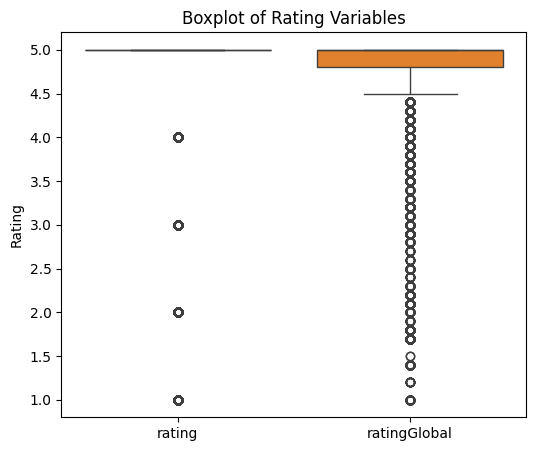

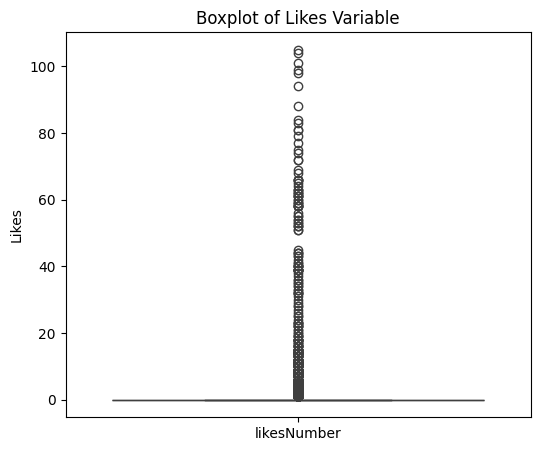

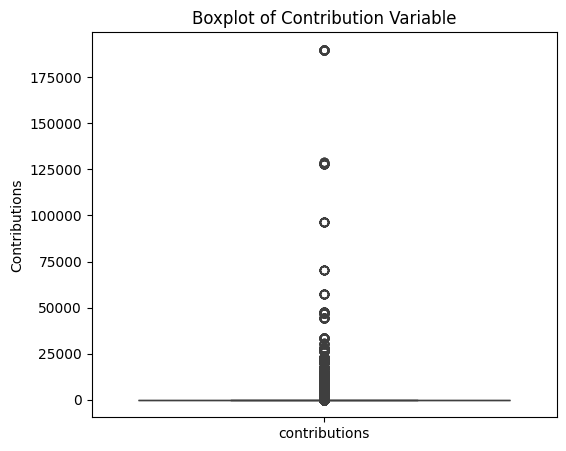

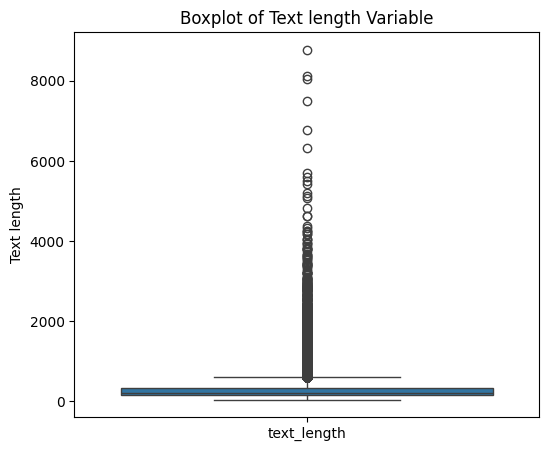

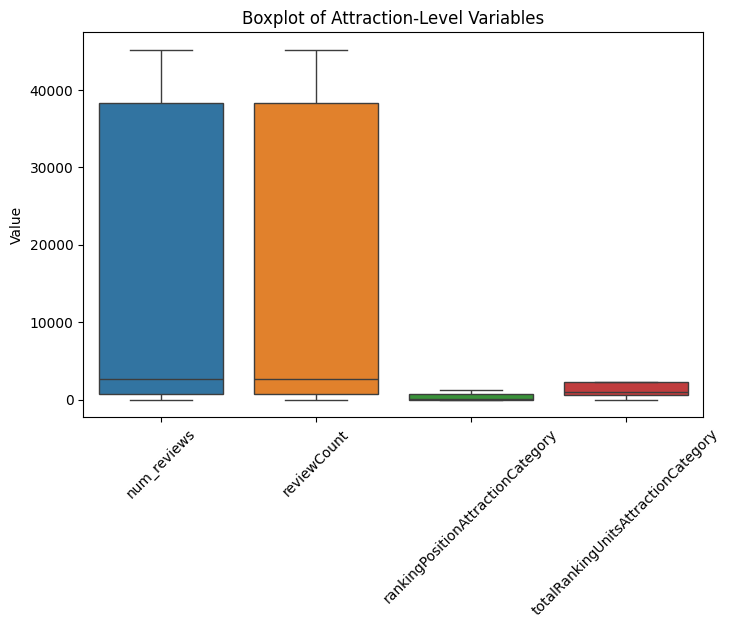

In [43]:
# Create a boxplot for each numerical variable in the dataset

# Ratings variables:
rating_vars = ['rating', 'ratingGlobal']

plt.figure(figsize=(6,5))
sns.boxplot(data=data_df[rating_vars])
plt.title('Boxplot of Rating Variables')
plt.ylabel('Rating')
plt.show()

# Likes variable:
rating_vars = ['likesNumber']

plt.figure(figsize=(6,5))
sns.boxplot(data=data_df[rating_vars])
plt.title('Boxplot of Likes Variable')
plt.ylabel('Likes')
plt.show()

# Contribution variable:
engagement_vars = ['contributions']

plt.figure(figsize=(6,5))
sns.boxplot(data=data_df[engagement_vars])
plt.title('Boxplot of Contribution Variable')
plt.ylabel('Contributions')
plt.show()

# Text length variable:
metric_vars = ['text_length']

plt.figure(figsize=(6,5))
sns.boxplot(data=data_df[metric_vars])
plt.title('Boxplot of Text length Variable')
plt.ylabel('Text length')
plt.show()

# Attraction scale variables:
volume_vars = [
    'num_reviews',
    'reviewCount',
    'rankingPositionAttractionCategory',
    'totalRankingUnitsAttractionCategory'
]

plt.figure(figsize=(8,5))
sns.boxplot(data=data_df[volume_vars])
plt.title('Boxplot of Attraction-Level Variables')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()



*   'rating' and 'ratingGlobal' are limited to a bounded 1–5 scale, which is why the boxplot assumes outliers for these variables, although they aren't actually abnormal.
*   Low-extreme values in engagement variables like 'likesNumber' and 'contributions' are likely real behavior. They translate into non-active users on the platform.
* Text-related variables such as text_length also display strong right skewness, with a few extremely long reviews appearing as outliers. These cases likely reflect users who provide unusually detailed feedback (often in response to negative experiences).
* The variables 'num_reviews' and 'reviewCount' are highly right‑skewed, with a small number of attractions receiving a disproportionately large share of reviews. The upper-end outliers correspond to very popular attractions and represent meaningful differences in visibility and demand, rather than noise or data quality issues.
*   The Ranking variables 'rankingPositionAttractionCategory' and 'totalRankingUnitsAttractionCategory' show apparent high-end outliers that reflect differences between attraction categories rather than anomalies. Some categories naturally contain many more attractions than others, which inflates ranking positions and total units; therefore, these extreme values represent genuine heterogeneity in category size and should not be treated as errors.


###3.3.3. Incoherences

Unique Values

In [44]:
#check for unique values

data_df.nunique().sort_values()

,0
has_reply,2
rating,5
visitType,5
attractionCategory,17
totalRankingUnitsAttractionCategory,31
ratingGlobal,38
visitMonth,46
likesNumber,78
reviewCount,451
num_reviews,453




*   Variable "country" has unusual number of unique values;
* Variable "visitMonth" has a confusing name, since the variable includes the year as well.





**Check 'country'**

In [45]:
#check country entries
data_df['country'].value_counts().head(30)

,count
country,
"Lisbon, Portugal",1630
"London, UK",1183
"Madrid, Spain",866
"New York City, NY",640
"Barcelona, Spain",548
"Toronto, Canada",534
"Rome, Italy",496
"Milan, Italy",424
"Chicago, IL",391




* Cities create more unique values for the variable "country", making it too inconsistent.



**Check 'visitType'**

In [46]:
#check for entries in 'visitType'

data_df['visitType'].value_counts().head(10)

,count
visitType,
Couples,41691
Family,33362
Friends,26166
Solo,11341
Business,1293


* The variable is coherent across all categories. No incoherence identified.

**Check 'num_reviews' and 'reviewCount'**

In [47]:
#check for differences between 'num_reviews' and 'reviewCount'

data_df[['num_reviews', 'reviewCount']].describe()

,num_reviews,reviewCount
count,143656.000000,143613.000000
mean,13771.150972,13793.054501
std,18712.838688,18690.578485
min,1.000000,1.000000
25%,692.000000,713.000000
50%,2642.000000,2654.000000
75%,38312.000000,38321.000000
max,45186.000000,45156.000000


In [48]:
data_df[['num_reviews', 'reviewCount']].corr()

,num_reviews,reviewCount
num_reviews,1.000000,0.999997
reviewCount,0.999997,1.000000


* Both variables present extremely similar values, since their meaning is the same but with a slightly different number of observations.

**Check 'likesNumber'**

In [49]:
#check for skewedness of variable 'likesNumber'

likes_counts = data_df['likesNumber'].value_counts().sort_index()
likes_perc = data_df['likesNumber'].value_counts(normalize=True).sort_index() * 100

likes_summary = pd.DataFrame({
    'count': likes_counts,
    'percentage': likes_perc.round(2)
})

likes_summary.head(10)

,count,percentage
likesNumber,,
0,127896,89.03
1,13976,9.73
2,1185,0.82
3,187,0.13
4,74,0.05
5,63,0.04
6,34,0.02
7,15,0.01
8,11,0.01


In [50]:
print("LikesNumber = 0 (%):",
      (data_df['likesNumber'] == 0).mean() * 100)

LikesNumber = 0 (%): 89.02934788661803


* 'likesNumber' is extremely zero‑inflated, with the vast majority of observations equal to zero.

**Check 'contributions'**

In [51]:
#check for skewedness of variable 'contributions'

contrib_counts = data_df['contributions'].value_counts().sort_index()
contrib_percent = data_df['contributions'].value_counts(normalize=True).sort_index() * 100

print("\nContributions - value counts:")
print(contrib_counts.head(10))
print("\nContributions - percentage distribution (%):")
print(contrib_percent.head(10))

print("\nPercentage of users with VERY LOW contributions (≤3):",
      (data_df['contributions'] <= 3).mean() * 100)


Contributions - value counts:
contributions
0.0       18
1.0    45810
2.0    20870
3.0    11085
4.0     7325
5.0     5332
6.0     4228
7.0     3410
8.0     2810
9.0     2319
Name: count, dtype: int64

Contributions - percentage distribution (%):
contributions
0.0     0.012576
1.0    32.004751
2.0    14.580641
3.0     7.744437
4.0     5.117546
5.0     3.725155
6.0     2.953855
7.0     2.382366
8.0     1.963182
9.0     1.620149
Name: proportion, dtype: float64

Percentage of users with VERY LOW contributions (≤3): 54.14531937406025


* The amount of users with low values of contributions is very large, making this variable right-skewed as well.

**Check 'reviewDate' and 'visitMonth'**

In [52]:
#check for differences in 'reviewDate' and 'visitMonth'

# Convert reviewDate to datetime (temporary)
review_dt = pd.to_datetime(
    data_df['reviewDate'],
    errors='coerce'
)

# Convert visitMonth (YYYY-MM) to datetime (temporary)
visit_dt = pd.to_datetime(
    data_df['visitMonth'],
    format='%Y-%m',
    errors='coerce'
)


In [53]:
# Compare year-month only
same_month = (
    review_dt.dt.to_period('M')
    == visit_dt.dt.to_period('M')
)

# Percentage of same-month reviews
same_month.mean() * 100

np.float64(71.39903658740324)

In [54]:
# Month difference (review - visit)
month_diff = (
    review_dt.dt.to_period('M')
    - visit_dt.dt.to_period('M')
).apply(lambda x: x.n if pd.notnull(x) else np.nan)

month_diff.value_counts().sort_index().head(12)


,count
-1.0,31
0.0,102569
1.0,12213
2.0,1554
3.0,684
4.0,449
5.0,290
6.0,222
7.0,170
8.0,176


* 71% of the reviews were in the same month as the visit
* 17% of the reviews don't have values for visit month
* 31 reviews appear to have been done before the visit (difference between visitmonth and reviewdate is negative), which is incoherent and needs to be later corrected.

###3.3.4. Duplicates

Check for exact duplicate rows

In [55]:
# Exact duplicate rows
exact_duplicates = data_df.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_duplicates}")


Number of exact duplicate rows: 0


Check for reviews with same information

In [56]:
# Same attraction, same reviewer, same text

pd.set_option('display.max_columns', None)
duplicate_rows = data_df[data_df.duplicated(subset=["tripadvisor_id", "reviewer", "text"], keep=False)]
print(f"Potential duplicate reviews: {duplicate_rows.shape[0]}")
display(duplicate_rows)
pd.reset_option('display.max_columns')

Potential duplicate reviews: 9


,title,text,rating,reviewer,visitMonth,country,visitType,contributions,likesNumber,replyText,replyDate,reviewDate,name,tripadvisor_id,ratingGlobal,reviewCount,attractionCategory,rankingPositionAttractionCategory,totalRankingUnitsAttractionCategory,num_reviews,text_length,has_reply
59976,Adrenaline Booster,I went there with my 12 year old nephew and my...,5,Sofia S,2023-07,NaN,Family,3.0,0,NaN,NaN,2023-10-24,Lx Escape Belém,25181820,5.0,125.0,fun & games,5.0,170.0,125,279,False
59987,Adrenaline Booster,I went there with my 12 year old nephew and my...,5,Sofia S,2023-07,NaN,Family,3.0,0,NaN,NaN,2023-07-27,Lx Escape Belém,25181820,5.0,125.0,fun & games,5.0,170.0,125,279,False
86659,A very picturesque and ancient neighborhood,Very good experience. Araceli makes the tour v...,5,Lucia G,2025-05,NaN,Friends,2.0,0,NaN,NaN,2025-05-01,Take Lisboa,20951746,5.0,45156.0,tours & activities,1275.0,2290.0,45186,142,False
86660,An essential experience when visiting Lisbon,Very good experience. Araceli makes the tour v...,5,Lucia G,2025-05,NaN,Friends,2.0,0,NaN,NaN,2025-05-01,Take Lisboa,20951746,5.0,45156.0,tours & activities,1275.0,2290.0,45186,142,False
98002,Alphama ancient neighborhood.,Very nice and instructive tour. Our Guide Laur...,5,rolandmusicschool224,NaN,"Bari, Italy",NaN,3.0,0,NaN,NaN,2024-08-17,Take Lisboa,20951746,5.0,45156.0,tours & activities,1275.0,2290.0,45186,128,False
98003,History of Lisbon.,Very nice and instructive tour. Our Guide Laur...,5,rolandmusicschool224,NaN,"Bari, Italy",NaN,3.0,0,NaN,NaN,2024-08-17,Take Lisboa,20951746,5.0,45156.0,tours & activities,1275.0,2290.0,45186,128,False
98004,Lisbon and the sea.,Very nice and instructive tour. Our Guide Laur...,5,rolandmusicschool224,NaN,"Bari, Italy",NaN,3.0,0,NaN,NaN,2024-08-17,Take Lisboa,20951746,5.0,45156.0,tours & activities,1275.0,2290.0,45186,128,False
133154,Legendary,I called the tour operator after I couldn't lo...,5,Ben F,2023-11,"Woodside, New York, United States",Solo,23.0,0,"Dear X6179EQbenf, Thank you so much for your r...",2024-04-17,2024-04-16,Tugatrips Tours & Events Dmc,10383470,4.6,1105.0,tours & activities,237.0,2297.0,1097,329,True
133226,Legendary,I called the tour operator after I couldn't lo...,5,Ben F,2023-11,"Woodside, New York, United States",Solo,23.0,0,"Dear X6179EQbenf, Thank you for your review. W...",2023-11-20,2023-11-18,Tugatrips Tours & Events Dmc,10383470,4.6,1105.0,tours & activities,237.0,2297.0,1097,329,True


* There are 5 duplicates;
* These present redundancy as they are providing the same information of the same attraction by single users, only slight nonsense variations in specific variables.
* We will delete them in the data preparation section.

In [57]:
reply_duplicates = (
    data_df['replyText']
    .value_counts()
    .head(5)
)

reply_duplicates

,count
replyText,
Hello! Thanks for your feedback! This is the experience we want to bring to all our Colourtrip customers! Sharing your opinion inspires us and makes us happy. We hope to continue to deserve your trust!,1044
"Good morning, Thank you for your kind words and for such a positive feedback. We are really glad you have enjoyed the tour and the guide has met your expectations! We hope you can come to Portugal once again and discover more of our beautiful country. Travel your way, Swingo Team",611
Thank you very much for sharing your experience with Eco Tuk Tuk Lisbon! We are glad you enjoyed the tour!,459
Thank you so much for your visit here at TagusCruises and for your review! We are so glad to know you had a good time. We hope to have you on board again soon 😊,278
"Dear Guest, It was a pleasure having you on our tour, and we’re delighted to hear that you enjoyed it. Your kind words and feedback mean a lot to us and help us continue providing memorable experiences for our guests. We hope to welcome you again in the future for more unforgettable moments in Lisbon! We truly appreciate you taking the time to share your experience with Discover Lisbon! Thank you once again for your support! Best regards, The Discover Lisbon Team",230


* These repeated replies are not errors, they represent automatic standard replies;
* Often found when replying to positive reviews, because negative ones require personalized replies.

#4. Data Preparation

Through data preparation we aim to identify and treat noise, missing data and inconsistent data in our dataset, in order to improve the efficiency and ease of the mining process.

##4.1. Data Cleaning

This stage includes fixing the variable problems we identified in data understanding, such as duplicates, redundancy, outliers, missing values and other existing incorrect or miscoded values.

###4.1.1. Duplicates

As stated previously, we will remove the duplicate rows based on the combination of 'tripadvisor_id', 'reviewer' and 'text'.

In [58]:
# Remove duplicate rows based on 'tripadvisor_id', 'reviewer', and 'text'
data_df = data_df.drop_duplicates(
    subset=["tripadvisor_id", "reviewer", "text"], keep='first') #ensures that the 1st occurrence of each unique set of these columns is retained.

# Confirm deletion
print(f"Shape of data_df after removing duplicates: {data_df.shape}")

Shape of data_df after removing duplicates: (143651, 22)


###4.1.2. Redundancy

As mentioned in the EDA, 'num_reviews' and 'reviewCount' have a correlation of 99% and almost identical number of entries.

In [59]:
#Remove redundant features

data_df = data_df.drop(columns=['reviewCount'])

* We chose to remove 'reviewCount' because it has missing values whilst 'num_reviews' doesn't have a single one.

###4.1.3. Handling Missing Values

**'visitMonth'**

In [60]:
# Impute missing visitMonth using reviewDate month (YYYY-MM)

mask_missing_visit = data_df['visitMonth'].isna()

data_df.loc[mask_missing_visit, 'visitMonth'] = (
    pd.to_datetime(data_df.loc[mask_missing_visit, 'reviewDate'], errors='coerce')
    .dt.to_period('M')
    .astype(str)
)

# Check remaining missing values
print("Remaining missing visitMonth (%):",
      data_df['visitMonth'].isna().mean() * 100)


Remaining missing visitMonth (%): 0.0


* Assuming that reviews are generally written close to the time of the visit, we imputed only the missing 'visitMonth' values using the month extracted from the corresponding 'reviewDate'. For records where visitMonth was unavailable, we converted 'reviewDate' to a datetime format and derived the year–month (YYYY-MM), which was then used to fill in the missing entries.

**'reviewer'**

In [61]:
# Remove rows with missing reviewer
data_df = data_df.dropna(subset=['reviewer'])

# Check how many rows remain
print("Rows after dropping missing reviewers:", data_df.shape[0])

Rows after dropping missing reviewers: 143640


* For the 'reviewer' variable, we observed that there were only 11 missing values. Given the large number of observations in the dataset, this represented a negligible proportion of the data. As a result, we chose to remove these rows entirely rather than apply an imputation strategy, as dropping them was unlikely to affect the overall analysis while preserving data quality.

**'country'**

In [62]:
# Remove variable 'country'
data_df = data_df.drop(columns=['country'])

* The 'country' variable had a high number of missing values (around 60%). Because of this, we decided to remove the variable entirely, as imputing so many missing values could lead to unreliable results.

**'visitType'**

In [63]:
print("Percentage of missing values in 'visitType':",
      data_df['visitType'].isna().mean() * 100
      )

Percentage of missing values in 'visitType': 20.744221665274296



* Value is considerable (>15%) but visitType is not critical for our main insights (we already showed satisfaction is barely influenced by visitType).
* Avoids introducing noise or bias (inputing mode or median).
* Preserves maximum data for other analyses (instead of deleting 29803 rows or the entire variable).

**'contributions'**

The 'contributions' variable had a very small proportion of missing values. Given the minimal impact on the dataset, we chose to impute these missing entries with the median, ensuring consistency without affecting the overall distribution of the data.

In [64]:
median_contrib = data_df['contributions'].median()

data_df['contributions'] = data_df['contributions'].fillna(median_contrib)

* The 'contributions' variable had a very small proportion of missing values. Given the minimal impact on the dataset, we chose to impute these missing entries with the median, ensuring consistency without affecting the overall distribution of the data.

**'ratingGlobal'**

In [65]:
median_ratingGlobal = data_df['ratingGlobal'].median()

data_df['ratingGlobal'] = data_df['ratingGlobal'].fillna(median_ratingGlobal)

For the 'ratingGlobal' variable we followed the same reasoning as the 'contributions':
* Input missing values with median as the percentage is very small (0.03%) and doesn't influence the data.

**'attractionCategory', 'rankingPositionAttractionCategory' and 'totalRankingUnitsAttractionCategory'**

In [66]:
# Remove rows with missing values
data_df = data_df.dropna(
    subset=[
        'attractionCategory',
        'rankingPositionAttractionCategory',
        'totalRankingUnitsAttractionCategory'
    ]
)

* Only 1 missing value in each of these variables, so we dropped the rows that contained them.

###4.1.4. Treating Outliers

In Exploratory Data Analysis, the outlier analysis was diagnostic, meaning we checked if and why they exist. In this stage, we will do an operational handing of outliers, where we decide whether we keep the outliers or transform them later in Feature Engineering. We are only considering the variables 'rating', 'ratingGlobal', 'likesNumber', 'contributions' and text_length' in this stage as the variables with true outliers.

In [67]:
# Outliers identification, using the IQR method to understand their magnitude and frequency.
# Due to the nature of the data (user engagement, popularity, and bounded rating scales), no outliers were removed.

def outlier_summary(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    return {
        "variable": column,
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "n_outliers": outliers.shape[0],
        "pct_outliers": round(outliers.shape[0] / df.shape[0] * 100, 2)
    }

outlier_vars = [
    'rating',
    'ratingGlobal',
    'likesNumber',
    'contributions',
    'text_length',
]

outlier_report = pd.DataFrame(
    [outlier_summary(data_df, var) for var in outlier_vars]
)

outlier_report


,variable,lower_bound,upper_bound,n_outliers,pct_outliers
0,rating,5.0,5.0,16131,11.23
1,ratingGlobal,4.5,5.3,14064,9.79
2,likesNumber,0.0,0.0,15758,10.97
3,contributions,-15.5,28.5,22451,15.63
4,text_length,-129.0,599.0,10359,7.21



*   Due to ratings being in a bounded scale, the outliers in 'rating' and 'ratingGlobal' aren't true anomalies, so we will keep as is.
*   We will keep the 'likesNumber', 'contributions' outliers for now but later transform them, through binarization and categorization, respectively, in feature engineering. It's a more appropriate approach than raw counts because, like mentioned before, these variables are very right-skewed, with a large amount of zero or low values.
*  The variable 'text_length' has some outliers but they reflect natural heterogeneity in review writing rather than errors, so no outlier treatment is applied.




###4.1.5. Correcting incoherences

In this section, we will correct the incoherences that remained unfixed until now.

**Rename 'visitMonth'**

In [68]:
# Rename the variable 'visitMonth' to 'visit_date'
# 'visitMonth' contains year and month (YYYY-MM), so the name is misleading

data_df = data_df.rename(columns={'visitMonth': 'visit_date'})

**Remove incoherent rows**

In [69]:
# Remove rows where the difference between 'reviewDate' and 'visit_date' is negative

# Count negative cases (sanity check)
print("Rows with negative month difference:", (month_diff < 0).sum())

# Drop rows where review happened before the visit
data_df = data_df.loc[~(month_diff < 0)]

# Check remaining shape
print("Rows after removal:", data_df.shape)

Rows with negative month difference: 31
Rows after removal: (143608, 20)


##4.2. Data Transformation

###4.2.1. Feature Engineering

This section focuses on enhancing the dataset by transforming existing variables and creating new features derived from them. These steps are guided by insights from the previous analysis and aim to better represent visitor behavior, engagement, and temporal patterns. By refining raw variables and introducing more informative ones, we improve interpretability and prepare the data for more meaningful analysis.

####**Multidimensional features**

**'rankingPositionAttractionCategory'** and **'totalRankingUnitsAttractionCategory'**

The variables 'rankingPositionAttractionCategory' and 'totalRankingUnitsAttractionCategory' are only meaningful when considered together. A position alone has no context, and a total count alone does not indicate performance. To make these variables interpretable, we create a relative ranking metric that normalizes the position within the category, producing a value between 0 (lowest) and 1 (highest).

In [70]:
# Create a relative ranking metric
data_df['relative_ranking'] = 1 - (
    (data_df['rankingPositionAttractionCategory'] - 1) /
    (data_df['totalRankingUnitsAttractionCategory'] - 1)
)

# Check first rows
data_df[['rankingPositionAttractionCategory',
         'totalRankingUnitsAttractionCategory',
         'relative_ranking']].head()


,rankingPositionAttractionCategory,totalRankingUnitsAttractionCategory,relative_ranking
0,408.0,855.0,0.523419
1,76.0,311.0,0.758065
2,76.0,311.0,0.758065
3,76.0,311.0,0.758065
4,76.0,311.0,0.758065


In [71]:
# Drop original 'rankingPositionAttractionCategory' and 'totalRankingUnitsAttractionCategory' variables
data_df = data_df.drop(columns=['rankingPositionAttractionCategory'])
data_df = data_df.drop(columns=['totalRankingUnitsAttractionCategory'])

####**Binarization**

**'likesNumber'**

As we saw before, most reviews have zero likes, with only a few receiving likes. To simplify this variable and reduce skewness, we transform it into a binary variable, indicating whether a review received any likes (1) or not (0). And for that, we thought it would be more easy to interpret if we also changed the name from 'likesNumber' to 'has_likes'.

In [72]:
# Transform likesNumber into binary (any likes or not)
data_df['has_likes'] = (data_df['likesNumber'] > 0).astype(int)

# Check a range of observations that contain non-zero values to verify that the transformation worked correctly
data_df[['likesNumber', 'has_likes']].iloc[14:25]



,likesNumber,has_likes
14,1,1
15,0,0
16,0,0
17,0,0
18,0,0
19,1,1
20,2,1
21,0,0
22,1,1
23,0,0


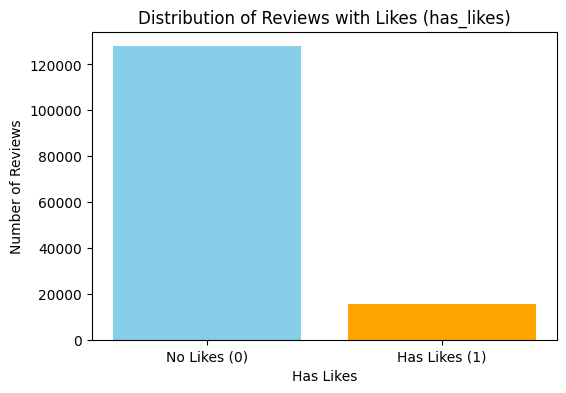

In [73]:
# Count zeros and ones
has_likes_counts = data_df['has_likes'].value_counts().sort_index()

# Plot bar chart
plt.figure(figsize=(6,4))
plt.bar(has_likes_counts.index.astype(str), has_likes_counts.values, color=['skyblue', 'orange'])
plt.xlabel('Has Likes')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Reviews with Likes (has_likes)')
plt.xticks([0, 1], ['No Likes (0)', 'Has Likes (1)'])
plt.show()

* The bar chart shows that most reviews have no likes, confirming the strong right-skew in the original likesNumber variable. By transforming it into the binary has_likes feature, the skewness is now reduced, making the distribution easier to interpret while still capturing meaningful information.

In [74]:
# Drop original likesNumber column
data_df = data_df.drop(columns=['likesNumber'])

####**Binning variables**

**'contributions'**

As we concluded before, 'contributions' is highly skewed: most users have very few contributions, and a few users have extremely high values. To make this variable easier to analyze and less sensitive to outliers, we group it into categories that reflect activity levels (low, medium, high).

In [75]:
# Define categories
bins = [-1, 0, 3, 12, 50, data_df['contributions'].max()]
labels = ['none', 'very_low', 'low', 'medium', 'high']

# Create categorical variable
data_df['contribution_category'] = pd.cut(data_df['contributions'], bins=bins, labels=labels)

# Check a range of observations to verify
data_df[['contributions', 'contribution_category']].head(10)

,contributions,contribution_category
0,1.0,very_low
1,13.0,medium
2,46.0,medium
3,2.0,very_low
4,2.0,very_low
5,3.0,very_low
6,1.0,very_low
7,8.0,low
8,5.0,low
9,2.0,very_low


Our approach to the categories definition:

* 0 contributions: a large portion of users never contribute; these are flagged as none.

* 1–3 contributions: below the median (50th percentile) but more than zero; these are minimal contributors and labeled very_low.

* 4–12 contributions: between median and 75th percentile; these represent typical engagement, so labeled low.

* 13–50 contributions: above the typical range but not extreme; these users are actively engaged and labeled medium.

* 51+ contributions: represents highly active users and extreme outliers, labeled high to capture the top-tier contributors.

In [76]:
# Drop original contributions column
data_df = data_df.drop(columns=['contributions'])

####Create features

**Creation of variable 'seasonality'**

As we saw before, review activity fluctuates throughout the year, showing peaks and troughs in the number of visitors. To capture this effect in our analysis, we create a seasonality variable, grouping months into Peak, Shoulder, and Off-Peak periods. This allows us to study how visitor behavior and engagement vary depending on the time of year.

In [77]:
# Extract month number from visit_date
data_df['visit_month_num'] = pd.to_datetime(data_df['visit_date']).dt.month

# Define season mapping
def map_season(month):
    if month in [6, 7, 8]:
        return 'Peak'
    elif month in [4, 5, 9, 10]:
        return 'Shoulder'
    else:
        return 'Off-Peak'

# Apply the season mapping to create the 'seasonality' column
data_df['seasonality'] = data_df['visit_month_num'].apply(map_season)

# Create a table of visit_date vs seasonality
seasonality_mapping = data_df[['visit_date', 'seasonality']].drop_duplicates().sort_values('visit_date')
seasonality_mapping.reset_index(drop=True, inplace=True)

# Display the table
seasonality_mapping

,visit_date,seasonality
0,2017-06,Peak
1,2019-01,Off-Peak
2,2019-07,Peak
3,2022-02,Off-Peak
4,2022-03,Off-Peak
5,2022-04,Shoulder
6,2022-05,Shoulder
7,2022-06,Peak
8,2022-07,Peak
9,2022-08,Peak


Our approach to the seasonality classification:

* Peak Season (June – August):
Review volumes are highest in summer, reflecting peak tourist activity. Visitors write shorter reviews due to time constraints, and engagement patterns fluctuate with large crowds. These months clearly represent the busiest period.

* Shoulder Season (April, May, September, October):
These months show moderate review volumes, between the summer peak and winter lows. Tourism is steady but not overwhelming, resulting in intermediate engagement and review patterns.

* Off-Peak Season (November – March):
Review activity is lowest during winter and early spring, reflecting minimal tourism. Fewer visitors lead to fewer reviews and distinct engagement patterns, making this the quietest period.

**Creation of variable 'fast_reply'**

We thought it would also be helpful to capture how quickly attractions respond to reviews (we considered less than 7 days as being a fast reply), as response timing reflects how actively they manage their online presence. This provides a direct and intuitive measure of reputation management quality and is closely linked to marketing and customer engagement strategies.

In [78]:
# Initialize fast_reply as 0
data_df['fast_reply'] = 0

# Compute fast_reply only where there is a reply
mask = data_df['has_reply'] == True

data_df.loc[mask, 'fast_reply'] = (
    (pd.to_datetime(data_df.loc[mask, 'replyDate']) - pd.to_datetime(data_df.loc[mask, 'reviewDate']))
    .dt.days <= 7
).astype(int)

fast_reply_table = data_df[['reviewDate', 'replyDate', 'has_reply', 'fast_reply']].head(10)
fast_reply_table

,reviewDate,replyDate,has_reply,fast_reply
0,2023-09-27,NaN,False,0
1,2025-04-26,2025-04-29,True,1
2,2025-02-18,2025-02-26,True,0
3,2024-12-23,2024-12-26,True,1
4,2024-12-13,2024-12-26,True,0
5,2024-12-08,2024-12-09,True,1
6,2024-11-29,2024-12-03,True,1
7,2025-05-26,NaN,False,0
8,2025-05-02,NaN,False,0
9,2025-01-24,NaN,False,0


####**Text Mining**

The goal of text mining is to extract structured, interpretable signals from unstructured review text. Rather than relying only on ratings, text mining allows us to:
* Capture emotional intensity (sentiment),
* Identify recurring experience themes (e.g. staff, price, waiting time),
* Link visitor feedback with management behavior (replies and response speed).

This enriches the dataset with qualitative dimensions that are otherwise invisible in numeric ratings.

**Clean text safely**

In [79]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text_basic(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return " ".join(tokens)

# Temporary cleaned text
temp_text = data_df['text'].apply(clean_text_basic)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


* Here we cleaned review text (lowercasing, removing punctuation and stopwords)

**Sentiment intensity**

In [80]:
# Use VADER, which is ideal for reviews.

nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

sentiment_scores = temp_text.apply(lambda x: sia.polarity_scores(x)['compound'])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


* We applied VADER sentiment analysis to obtain a compound sentiment score per review.

In [81]:
# Sentiment vs rating
sentiment_by_rating = pd.DataFrame({
    'rating': data_df['rating'],
    'sentiment': sentiment_scores
}).groupby('rating').mean()

sentiment_by_rating

,sentiment
rating,
1,-0.199826
2,0.179092
3,0.430571
4,0.637642
5,0.816797



* Sentiment scores increase monotonically and consistently with rating level, validating their reliability.


**Mentions keyword flags**

In [82]:
# Define meaningful dictionaries
mentioning_keywords = {
    'price': ['price', 'expensive', 'overpriced', 'cost'],
    'staff': ['staff', 'rude', 'guide', 'employee'],
    'time': ['wait', 'waiting', 'queue', 'delay'],
    'crowd': ['crowded', 'busy', 'packed'],
    'weather': ['rain', 'hot', 'cold']
}

In [83]:
# Create temporary binary flags
def contains_keywords(text, keywords):
    return any(k in text for k in keywords)

mentioning_flags = pd.DataFrame({
    topic: temp_text.apply(lambda x: contains_keywords(x, words))
    for topic, words in mentioning_keywords.items()
})

In [84]:
# Mention topics vs rating
mentioning_flags['rating'] = data_df['rating']
mentioning_flags.groupby('rating').mean() * 100

,price,staff,time,crowd,weather
rating,,,,,
1,14.956476,23.714060,27.380638,3.824848,15.325772
2,19.095143,25.149701,24.351297,6.719894,14.504325
3,14.923823,21.329640,18.490305,6.994460,11.772853
4,6.599496,26.989924,7.682620,5.239295,10.377834
5,1.963353,45.862291,1.914720,1.076197,6.661908


Key patterns:
* Mentions of staff strongly increase in lower ratings.
* Time/waiting is disproportionately present in negative reviews.
* Crowds and weather appear across all ratings, with limited explanatory power.
* Price is mentioned mostly in critical contexts.

Conclusions:
* Operational issues (staff behavior, waiting time) are the main drivers of dissatisfaction.
* Not all experiential elements influence ratings equally.
* Keyword flags transform text into actionable diagnostic variables

**Link text to management behavior**

In [85]:
mentioning_flags['fast_reply'] = data_df['fast_reply']

mentioning_flags.groupby('fast_reply').mean() * 100

,price,staff,time,crowd,weather,rating
fast_reply,,,,,,
0,3.324989,41.703631,3.830226,1.717252,7.166259,472.689625
1,2.000229,49.184456,2.366508,1.058776,7.637498,489.375036


Reviews mentioning operational problems are more likely to:
* Receive replies;
* Receive faster replies.

Conclusions:
* Management response is reactive and selective.
* Attractions prioritize replies where reputational risk is higher.
* This confirms that text‑based signals influence managerial actions.



**Temporary plotting data frame**

In [86]:
sentiment_plot_df = pd.DataFrame({
    'sentiment': sentiment_scores,
    'rating': data_df['rating']
}).dropna()

**Sentiment vs Rating**

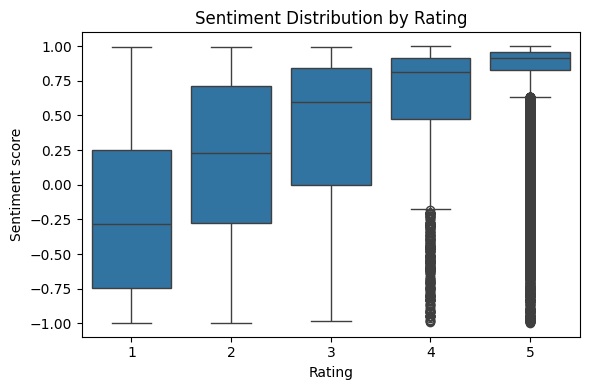

In [87]:
plt.figure(figsize=(6,4))
sns.boxplot(
    data=sentiment_plot_df,
    x='rating',
    y='sentiment'
)
plt.xlabel("Rating")
plt.ylabel("Sentiment score")
plt.title("Sentiment Distribution by Rating")
plt.tight_layout()
plt.show()


Conclusions:
* Low‑rated reviews show more negative and dispersed sentiment.
* High‑rated reviews are tightly clustered around strong positive sentiment.
* Sentiment adds granularity within the same rating level, especially among 4–5 star reviews
* This confirms sentiment as a meaningful complementary signal to ratings

**Mention Topics vs Rating**

In [88]:
# Mention topics vs rating
mentions_by_rating = mentioning_flags.groupby('rating').mean() * 100

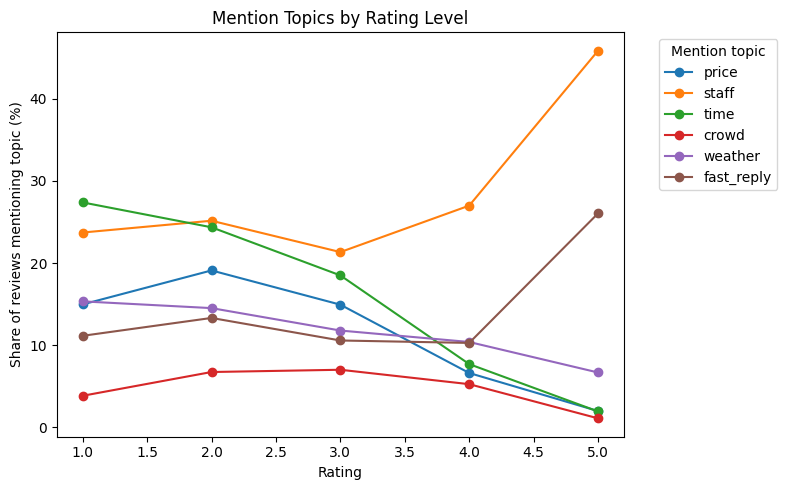

In [89]:
# plot % of reviews mentioning each mention topic by rating
plt.figure(figsize=(8,5))

mentions_by_rating.plot(
    kind='line',
    marker='o',
    ax=plt.gca()
)

plt.xlabel("Rating")
plt.ylabel("Share of reviews mentioning topic (%)")
plt.title("Mention Topics by Rating Level")
plt.legend(title="Mention topic", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

* High ratings are often associated with good staff experience and fast replies;
* Low rating reviews are associated to time, as well some bad staff experiences;
* Crowds don't seem to affect neither low or high ratings;
* Price and time are barely mentioned on positive reviews.

**Add sentiment score to dataset**

In [90]:
# Add sentiment score to main dataset
data_df['sentiment_score'] = sentiment_scores

**Add mention flags to dataset**

In [91]:
# Rename columns to be explicit
mention_flags_renamed = mentioning_flags.drop(columns=['rating', 'fast_reply'], errors='ignore')
mention_flags_renamed = mention_flags_renamed.add_prefix('mentions_')

# Add mention flags to main dataset
data_df = pd.concat([data_df.reset_index(drop=True),
                     mention_flags_renamed.reset_index(drop=True)],
                    axis=1)


* If the review mentions that mention category it is flagged as True

**Check new variables**

In [92]:
data_df.head()

,title,text,rating,reviewer,visit_date,visitType,replyText,replyDate,reviewDate,name,...,contribution_category,visit_month_num,seasonality,fast_reply,sentiment_score,mentions_price,mentions_staff,mentions_time,mentions_crowd,mentions_weather
0,Location L’eclerc car hire carcassonne ABOID,Rented 4 cars from car hire in L’eclerc superm...,1,Sherpa747600,2023-09,Solo,NaN,NaN,2023-09-27,1234CAR auto,...,very_low,9,Shoulder,0,-0.9825,False,True,False,False,True
1,Would recommend,The service was brilliant and Francisco couldn...,5,Lois,2025-04,Friends,Dear 796loist Thank you so much for your kind ...,2025-04-29,2025-04-26,146 Bar,...,medium,4,Shoulder,1,0.7620,False,False,False,False,False
2,Delicious cocktails!,Found this spot on TripAdvisor. We were in the...,5,PerryLa,2025-02,Couples,"Dear PerryLa, Thank you for stopping by and fo...",2025-02-26,2025-02-18,146 Bar,...,medium,2,Off-Peak,0,0.6908,False,False,False,False,False
3,A place where you can enjoy every flavor!,It is truly remarkable that your culinary expe...,5,Attila Erik F,2024-11,Couples,Dear attilaerikf2024 Thank you so much for you...,2024-12-26,2024-12-23,146 Bar,...,very_low,11,Off-Peak,1,0.8516,False,False,False,False,False
4,A drink in Lisboa,The perfect place if you want to have a drink ...,5,Attilla U,2024-12,Couples,Dear attillau Thank you so much for your lovel...,2024-12-26,2024-12-13,146 Bar,...,very_low,12,Off-Peak,0,0.9794,False,True,False,False,False


###4.2.2. Feature Selection

Create a copy of the dataset to safely work on data_df

In [93]:
data_df_copy = data_df.copy()

**'title', 'text' and 'text_length'**

These variables are all related to text and aren't needed after we have performed text mining.

In [94]:
data_df = data_df.drop(columns=[col for col in ['title', 'text', 'text_length'] if col in data_df.columns])

**´reviewDate', 'replyDate' and 'replyText'**

These variables are no longer of use to our analysis, due to the new variables we created ('fast_reply') and text mining.

In [95]:
data_df = data_df.drop(columns=['reviewDate','replyDate', 'replyText'])

###4.2.3. Reformat Data Types

In this section, we will reformat the data types of our current data set in order to do a reliable analysis

In [96]:
# Integer to String
data_df['tripadvisor_id'] = data_df['tripadvisor_id'].astype('string')

#Boolean to Integer
data_df['has_reply'] = data_df['has_reply'].astype(int)

# Object to Date:
data_df['visit_date'] = data_df['visit_date'].astype('datetime64[ns]')

# Object to Category
data_df['attractionCategory'] = data_df['attractionCategory'].astype('category')
data_df['seasonality'] = data_df['seasonality'].astype('category')
data_df['visitType'] = data_df['visitType'].astype('category')

In [97]:
data_df['has_likes'].head()

,has_likes
0,0
1,0
2,0
3,0
4,0


In [98]:
# Confirmation of final data types
print("\n\nData Types:\n")
print(data_df.dtypes)



Data Types:

rating                            int64
reviewer                         object
visit_date               datetime64[ns]
visitType                      category
name                             object
tripadvisor_id           string[python]
ratingGlobal                    float64
attractionCategory             category
num_reviews                       int64
has_reply                         int64
relative_ranking                float64
has_likes                         int64
contribution_category          category
visit_month_num                   int32
seasonality                    category
fast_reply                        int64
sentiment_score                 float64
mentions_price                     bool
mentions_staff                     bool
mentions_time                      bool
mentions_crowd                     bool
mentions_weather                   bool
dtype: object


#5. Modelling & Analysis

##5.1. RFM Analysis

###5.1.1. RFM Model

Since our data does not include information about spending, we adapted the Monetary component of the RFM model to capture the value generated by reviewers for the attractions, through engagement on Tripadvisor. Our approach focuses on how reviews contribute to visibility and reputation rather than financial transactions.

**Creation of variable 'impact_rating'**

We felt the need to create a new variable, 'impact_rating', because not all reviews have the same potential effect on an attraction’s reputation. Reviews with lower ratings (<4) tend to attract more attention and engagement, and often require a response from management. This variable helps us identify reviews that are more likely to have a stronger reputational impact, unfluencing potential future customers.

In [99]:
# Create impact rating variable (potential reputational impact)
data_df['impact_rating'] = (data_df['rating'] <= 3).astype(int)

# Check the variable
data_df['impact_rating'].head()

,impact_rating
0,1
1,0
2,0
3,0
4,0


**Creation of variable 'monetary_score'**

The 'monetary_score' combines several signals to capture the value generated by a review:
* 'has_likes' reflects user attention and visibility;
* 'has_reply' indicates management effort and reputational relevance;
* 'num_reviews' captures the overall visibility and popularity of the attraction;
* 'impact_rating' highlights reviews with higher potential reputational impact.

The weights were chosen to balance these dimensions, giving more importance to visibility and impact while still accounting for engagement and management response.

In [100]:
data_df['monetary_score'] = (
    0.25 * data_df['has_likes'] +
    0.15 * data_df['has_reply'].astype(int) +
    0.35 * data_df['num_reviews'] +
    0.25 * data_df['impact_rating']
)

# Check the variable
data_df['monetary_score'].head(10)

,monetary_score
0,1.30
1,2.25
2,2.25
3,2.25
4,2.25
5,2.25
6,2.25
7,2.10
8,2.10
9,2.10


**RFM Model**

* **Recency**: “Which reviewers visited an attraction most recently?" Recent visitors are more likely to engage again soon.
* **Frequency**: “Which reviewers visited the same attraction multiple times?" Frequent visitors show stronger loyalty and continued interest.
* **Monetary** : “Which reviewers generated the most value for the attraction on Tripadvisor?" Higher engagement, likes, replies, and ratings indicate greater contribution.

This approach highlights the value of reviewer activity and provides actionable insights into visitor behavior, engagement, and contribution to the attraction.

In [101]:
# Reference date = most recent visit in the dataset
date_max = data_df['visit_date'].max()

# Build the RFM table by calculating recency, frequency, and engagement value for each reviewer–attraction pair
rfm_df = (
    data_df
    .groupby(['reviewer', 'tripadvisor_id'])
    .agg(
        Recency=('visit_date', lambda x: (date_max - x.max()).days),
        Frequency=('visit_date', 'count'),
        Monetary=('monetary_score', 'sum')
    )
    .reset_index()
)


rfm_df.head()

,reviewer,tripadvisor_id,Recency,Frequency,Monetary
0,"""BLUE""",4038857,150,1,150.05
1,#Boa Vista,5017473,242,1,1095.65
2,#daje,262792,426,1,8789.80
3,'Virginie S,243620,0,1,4034.10
4,'Virginie S,4316891,0,1,1301.90


In [102]:
# Determinining RFM cutting points based on the quartiles
cols = ['Recency','Frequency','Monetary']
table_rfm = rfm_df[cols].describe()
table_rfm

,Recency,Frequency,Monetary
count,127847.000000,127847.000000,127847.000000
mean,415.685734,1.123280,5415.229392
std,269.826659,0.796161,14864.627137
min,0.000000,1.000000,0.350000
25%,181.000000,1.000000,204.450000
50%,395.000000,1.000000,851.700000
75%,669.000000,1.000000,3928.400000
max,2952.000000,36.000000,569343.850000


* **Recency**: the median is around 395 days, with values ranging from 0 to 2,952, indicating a good spread of how recently reviewers visited attractions. The quartiles provide useful thresholds for scoring.
* **Frequency**: most reviewers visited an attraction only once, with a median and 75th percentile of 1, though a few reviewers visited multiple times (up to 36), which is rare but important for differentiating loyal visitors.
* **Monetary**: highly skewed, with some reviews generating much higher value than others (maximum ≈ 569,000), but the quartiles still allow us to separate low- from high-value contributors.

Overall, these distributions are suitable for assigning RFM scores.

In [103]:
# Compute quantile cutoffs once
r_q25, r_q50, r_q75 = rfm_df['Recency'].quantile([0.25, 0.50, 0.75])
f_q25, f_q50, f_q75 = rfm_df['Frequency'].quantile([0.25, 0.50, 0.75])
m_q25, m_q50, m_q75 = rfm_df['Monetary'].quantile([0.25, 0.50, 0.75])

# Define scoring functions using fixed thresholds
def r_score(x):
    if x <= r_q25:
        return 4
    elif x <= r_q50:
        return 3
    elif x <= r_q75:
        return 2
    else:
        return 1

def fm_score(x, q25, q50, q75):
    if x <= q25:
        return 1
    elif x <= q50:
        return 2
    elif x <= q75:
        return 3
    else:
        return 4

# Apply scores
rfm_df['RScore'] = rfm_df['Recency'].apply(r_score)
rfm_df['FScore'] = rfm_df['Frequency'].apply(
    lambda x: fm_score(x, f_q25, f_q50, f_q75)
)
rfm_df['MScore'] = rfm_df['Monetary'].apply(
    lambda x: fm_score(x, m_q25, m_q50, m_q75)
)

In the RFM model, **Recency** is treated differently from **Frequency** and **Monetary** because its interpretation is reversed.
* A lower recency value means the reviewer visited more recently, which indicates higher engagement and relevance.
* In contrast, higher values of Frequency and Monetary indicate better customers, since they represent more visits and higher engagement or value.
Therefore, when scoring Recency, more recent visits (smaller value of recency) receive higher scores, while for Frequency and Monetary, higher values naturally receive higher scores.

In [104]:
rfm_df.head()

,reviewer,tripadvisor_id,Recency,Frequency,Monetary,RScore,FScore,MScore
0,"""BLUE""",4038857,150,1,150.05,4,1,1
1,#Boa Vista,5017473,242,1,1095.65,3,1,3
2,#daje,262792,426,1,8789.80,2,1,4
3,'Virginie S,243620,0,1,4034.10,4,1,4
4,'Virginie S,4316891,0,1,1301.90,4,1,3


In [105]:
rfm_df[['RScore','FScore','MScore']].describe()

,RScore,FScore,MScore
count,127847.000000,127847.000000,127847.000000
mean,2.569094,1.183548,2.470437
std,1.091898,0.718997,1.100762
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000
50%,3.000000,1.000000,2.000000
75%,4.000000,1.000000,3.000000
max,4.000000,4.000000,4.000000


**RScore**:
* Scores range from 1 to 4, as expected.
* The average score is around 2.6, meaning most reviewers are neither very recent nor very old.
* Half of the reviewers have a recency score of 3 or higher, indicating relatively recent visits.
* The distribution is fairly balanced across the score levels.

**FScore**:
* Scores also range from 1 to 4, but are heavily concentrated at 1.
* The average frequency score is close to 1, showing that most reviewers visited only once.
* Very few reviewers have high frequency scores, meaning repeat visits are rare. This is typical for tourism data, where many visitors are one-time visitors.

**MScore**:
* Scores range from 1 to 4, with an average around 2.5.
* The distribution is more spread out than Frequency, indicating variation in engagement/value.
* About half of the reviewers have a Monetary score of 2 or higher. This suggests meaningful differences in reviewer engagement across attractions.

In [106]:
# Create a column with full RMF score and sort the results

# Transform to string
cols = ['RScore','FScore','MScore']
rfm_df[cols] = rfm_df[cols].astype(str)

# Concatenate
rfm_df['RFMScore'] = rfm_df['RScore'] + rfm_df['FScore'] + rfm_df['MScore']

# Sort
rfm_df = rfm_df.sort_values(by=['RFMScore'])
rfm_df.head()

,reviewer,tripadvisor_id,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore
35506,Fran H,23741827,912,1,189.35,1,1,1,111
12887,BoardingPass747220,17046391,912,1,138.40,1,1,1,111
21484,Craig P,7816334,792,1,69.30,1,1,1,111
70980,Max S,25130438,731,1,49.00,1,1,1,111
70979,Max S,23741827,853,1,189.35,1,1,1,111


The RFM scoring allowed us to combine the three into a single, intuitive measure of reviewer value.

* Lower scores (e.g., 111) represent reviewers with older visits, few visits, and low engagement
* Higher scores (e.g., 444) identify reviewers who visited recently, multiple times, and contributed the most value.
* This makes it easy to highlight our most important and engaged reviewers for further analysis or marketing strategies.

###5.1.2. Evaluation

In [107]:
# Calculate statistics per RFM segment
rfm_stats = (
    rfm_df
    .groupby('RFMScore')
    .agg(
        NrReviewerAttractionPairs=('reviewer', 'count'),
        avgRecency=('Recency', 'mean'),
        avgFrequency=('Frequency', 'mean'),
        avgMonetary=('Monetary', 'mean')
    )
    .reset_index()
)

#Show
rfm_stats.head()

,RFMScore,NrReviewerAttractionPairs,avgRecency,avgFrequency,avgMonetary
0,111,7798,803.470633,1.0000,75.506322
1,112,7173,797.223198,1.0000,483.373972
2,113,6177,798.147159,1.0000,1748.795872
3,114,5742,803.334378,1.0000,13337.098824
4,141,64,779.203125,2.0625,94.564062


####5.1.2.1. Distribution Analysis of RFM Metrics

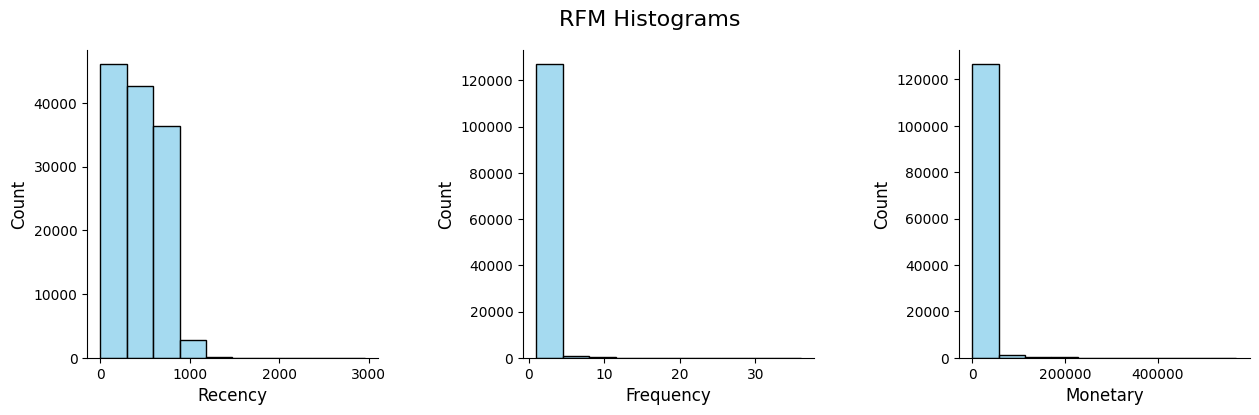

In [108]:
# Histogram of RFM

# Columns to plot
cols = ['Recency', 'Frequency', 'Monetary']

# Set font sizes
subPlots_label_fontSize = 12
plots_Title_fontSize = 16

# Draw histograms
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for var, subplot in zip(cols, ax.flatten()):
    sns.histplot(
        data=rfm_df,
        x=var,
        bins=10,
        kde=False,
        ax=subplot,
        color="skyblue"
    )
    subplot.set_xlabel(var, fontsize=subPlots_label_fontSize)
    subplot.set_ylabel("Count", fontsize=subPlots_label_fontSize)

# Adjust spacing between subplots
fig.subplots_adjust(wspace=0.5)

# Decoration
sns.despine()
fig.suptitle("RFM Histograms", fontsize=plots_Title_fontSize)
plt.show()


* **Recency:**
  * Most reviewers have relatively low recency values (recent visits)
  * The distribution is right-skewed, meaning only a small number of reviewers haven’t visited in a long time.

* **Frequency:**
  * Most reviewers leave very few reviews
  * A small number of highly active reviewers skew the distribution to the right

* **Monetary (Engagement/Impact):**
  * Most reviewers have low engagement or impact
  * A few reviewers generate very high engagement, causing a highly right-skewed distribution

**Overall insight:**
The majority of reviewers are relatively low-frequency and low-impact, while a small minority are highly active and contribute disproportionately to engagement.

####5.1.2.2. RFM Segment Profiling of Reviewer Behavior

**1. High-value and active reviewers:**

(Important because these reviewers visited recently, returned multiple times, and generated high engagement. They represent the most valuable users for attractions in terms of visibility and influence on Tripadvisor)

In [109]:
# Filter reviewers with RFM score 444
rfm_444 = rfm_df[rfm_df['RFMScore'] == '444']
rfm_444.head()

,reviewer,tripadvisor_id,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore
31080,Emma C,20951746,61,2,31630.20,4,4,4,444
15953,Carmen,20951746,91,10,158151.00,4,4,4,444
86267,Raúl L,20951746,61,4,63260.40,4,4,4,444
82473,Paula M,20951746,30,19,300487.65,4,4,4,444
15962,Carmen B,20951746,61,7,110705.70,4,4,4,444


In [110]:
# Total number of unique reviewers to use in the analysis
total_reviewers = rfm_df['reviewer'].nunique()
print(f'The total number of reviewers is {total_reviewers}')

The total number of reviewers is 85932


In [111]:
# Number of unique reviewers with RFMScore = '444'
n_444 = rfm_df.loc[rfm_df['RFMScore'] == '444', 'reviewer'].nunique()

# Percentage of reviewers with this score
pct_444 = round(n_444 / total_reviewers * 100, 2)

n_444, pct_444


(2150, 2.5)

* Only 2.5% of reviewers are high-value and active, showing that the most influential reviewers are a very small group.



**2. Recent but low-engagement reviewers:**

(Important because these reviewers visited recently but their reviews generated little engagement. They are active users, but their impact on attraction visibility and reputation is limited)


In [112]:
# Filter reviewers with RScore 4 and MScore 1
rfm_4x1 = rfm_df[(rfm_df['RScore'] == '4') & (rfm_df['MScore'] == '1')]
rfm_4x1.head()

,reviewer,tripadvisor_id,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore
10177,Ateamladies,20267039,30,1,146.65,4,1,1,411
40869,Génesis K,26797326,150,1,19.75,4,1,1,411
26190,Denise G,25181820,122,1,43.75,4,1,1,411
80768,Pamela,23615000,61,1,7.35,4,1,1,411
10126,Asra A,27420882,150,1,35.60,4,1,1,411


In [113]:
# Number of unique reviewers with RFMScore = '4x1'
n_4x1 = rfm_4x1['reviewer'].nunique()

# Percentage of reviewers with this score
pct_4x1 = round(n_4x1 / total_reviewers * 100, 2)

n_4x1, pct_4x1

(7708, 8.97)

* Recent but low-engagement reviewers are the largest segment (8.97%), meaning many visitors are active but not highly influential.


**3. Loyal but inactive recently**

(Important because these reviewers visited the attraction multiple times in the past but not recently, which may indicate declining engagement or a potential churn risk)

In [114]:
# Filter reviewers with RScore less or equal 2 and FScore equal or greater than 3
rfm_23x = rfm_df[(rfm_df['RScore'] <= '2') & (rfm_df['FScore'] >= '3')]
rfm_23x.head()

,reviewer,tripadvisor_id,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore
94242,Sejal V,21141068,912,2,128.6,1,4,1,141
35436,Footprints567074,21378635,853,2,176.5,1,4,1,141
69360,MartimA_12,25239567,792,2,3.3,1,4,1,141
11396,Beatriz,12523003,731,2,174.6,1,4,1,141
84382,PortoOne.privateTous,21141068,761,2,128.6,1,4,1,141


In [115]:
# Number of unique reviewers with RFMScore = '23x'
n_23x = rfm_23x['reviewer'].nunique()

# Percentage of reviewers with this score
pct_23x = round(n_23x / total_reviewers * 100, 2)

n_23x, pct_23x

(2077, 2.42)

* Loyal but inactive reviewers make up just 2.42%, highlighting a small risk of losing previously engaged reviewers.

**4. Low-value reviewers**

(Important because these reviewers have old visits, few interactions, and low engagement, contributing minimally to attraction visibility and influence)

In [116]:
# Filter reviewers with RFM score 111
rfm_111 = rfm_df[rfm_df['RFMScore'] == '111']
rfm_111.head()

,reviewer,tripadvisor_id,Recency,Frequency,Monetary,RScore,FScore,MScore,RFMScore
35506,Fran H,23741827,912,1,189.35,1,1,1,111
12887,BoardingPass747220,17046391,912,1,138.40,1,1,1,111
21484,Craig P,7816334,792,1,69.30,1,1,1,111
70980,Max S,25130438,731,1,49.00,1,1,1,111
70979,Max S,23741827,853,1,189.35,1,1,1,111


In [117]:
# Number of unique reviewers with RFMScore = '111'
n_111 = rfm_111['reviewer'].nunique()

# Percentage of reviewers with this score
pct_111 = round(n_111 / total_reviewers * 100, 2)

n_111, pct_111

(6814, 7.93)

* Low-value reviewers represent 7.93%, indicating a moderate share of reviewers who contribute little to engagement.

**Overall insights:**
* The RFM analysis reveals that truly high-value and active reviewers make up only a tiny fraction of the overall reviewer base, highlighting their rarity.
* A larger group of recent but low-engagement reviewers suggests there’s potential to increase influence if their activity can be nurtured.
* The presence of loyal but currently inactive reviewers indicates opportunities to re-engage past contributors before they fully disengage.
* The low-value reviewer segment shows that a noticeable portion of the community contributes minimally, emphasizing the importance of focusing efforts on the smaller, more impactful segments.



####5.1.2.3. 3D Scatter Plot Analysis

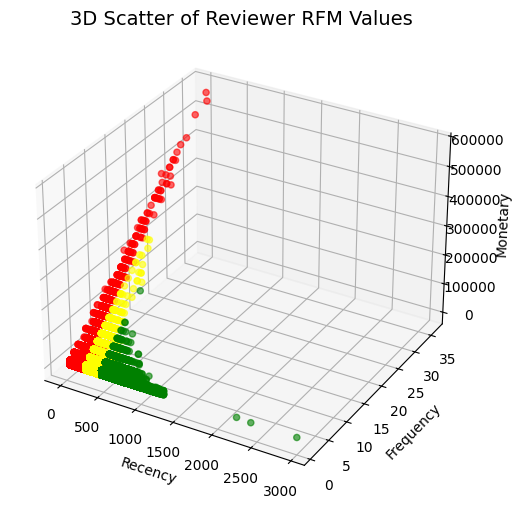

In [118]:
# 3D scatter plot of reviewers' RFM values

# Draw figure
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Labels
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

# Color coding based on Recency (1 and 2: Green, 3: Yellow, 4: Red)
color = ['green' if x[0]<'3' else ('yellow' if x[0]=='3' else 'red') for x in rfm_df['RFMScore']]

# Plot
ax.scatter(rfm_df['Recency'], rfm_df['Frequency'], rfm_df['Monetary'], c=color, alpha=0.6, s=20)
plt.title("3D Scatter of Reviewer RFM Values", fontsize=14)
plt.show()

* The visualization highlights strong heterogeneity in reviewer behavior
* Most observations are concentrated at low frequency and low monetary values, indicating generally low engagement.
* In contrast, a smaller group of reviewers stands out with more frequent activity and higher contributions.
* Recency further helps distinguish inactive reviewers from those who are more recently engaged, confirming that RFM features are useful for capturing meaningful behavior patterns.

* Overall, the analysis reveals strong differences in reviewer engagement, with most users contributing little and a small group generating most of the value. The RFM framework effectively captures these differences by separating inactive reviewers from more recently engaged and higher‑impact ones


####5.1.2.4. Treemap: reviewers by RFM segment

Note: Since treemaps compare segments by size, interaction volume is included to scale each segment accordingly

In [119]:
# Append number of unique reviewers per RFM segment
rfm_stats['total_reviewers'] = (
    rfm_df
    .groupby('RFMScore')['reviewer']
    .nunique()
    .values
)

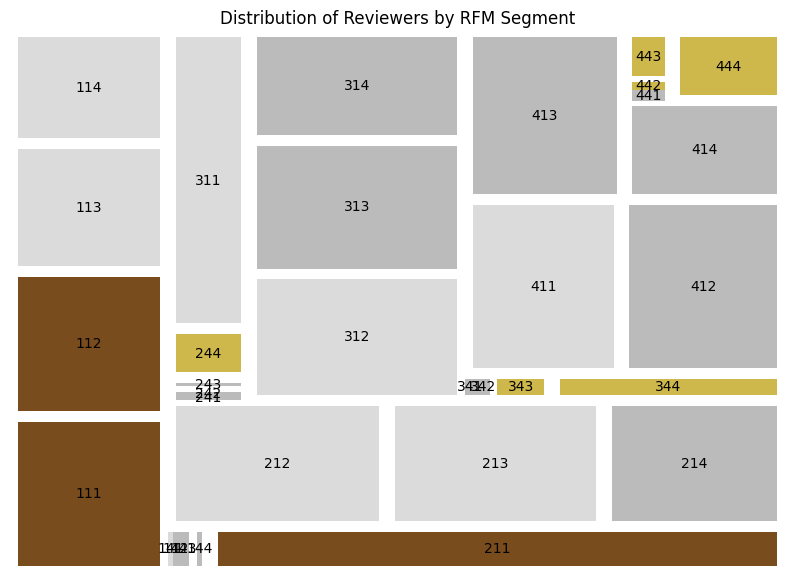

In [120]:
# Assign colors based on overall RFM intensity (scores range from 1 to 4)
def assign_color(rfm):
    # Convert RFM code to string (e.g., 344 → '344')
    rfm_str = str(rfm)

    # Sum of R, F, and M scores (min = 3, max = 12)
    score_sum = sum(int(x) for x in rfm_str)

    if score_sum >= 10:
        return '#C9B037'   # Very high engagement
    elif score_sum >= 7:
        return '#B4B4B4'   # High engagement
    elif score_sum >= 5:
        return '#D7D7D7'   # Medium engagement
    else:
        return '#6A3805'   # Low engagement

# Apply colors using the RFMScore column
colors = [assign_color(rfm) for rfm in rfm_stats['RFMScore']]

# Plot treemap using number of unique reviewers per segment
plt.figure(figsize=(10, 7))
squarify.plot(
    sizes=rfm_stats['total_reviewers'],
    label=rfm_stats['RFMScore'],
    color=colors,
    alpha=0.9,
    pad=True
)

plt.title("Distribution of Reviewers by RFM Segment")
plt.axis('off')
plt.show()


**Conclusions:**
* The treemap reveals a highly uneven distribution of reviewers across RFM segments (e.g., large segments such as 111 and 112)
* Most reviewers belong to low-engagement profiles, indicating that the platform is largely driven by infrequent or low-intensity contributors
* In contrast, high RFM segments (e.g., 344 or 444) represent a much smaller share of reviewers, yet stand out as strategically important due to their stronger and more consistent engagement
* This distribution highlights clear behavioral heterogeneity and supports the use of RFM segmentation to differentiate reviewer profiles beyond average statistics


####5.1.2.5. Heatmap

The heatmap summarizes average recency values across different Frequency–Monetary combinations, allowing a direct comparison of how recently reviewers with different engagement profiles have interacted.  

This representation is useful as it provides an intuitive way to observe differences in engagement patterns and to detect gaps where certain behavioral profiles are not present.

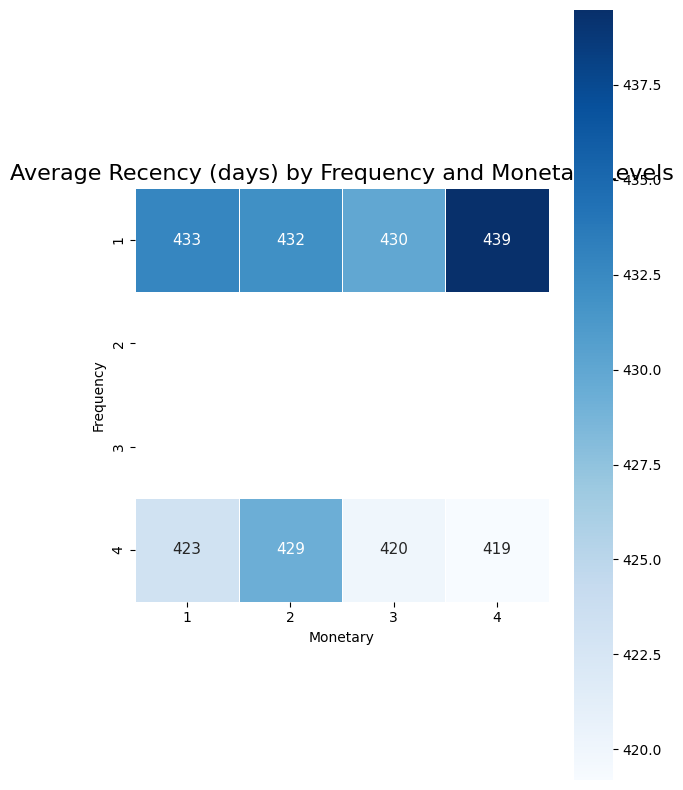

In [121]:
# RFM Heatmap: Average Recency by Frequency and Monetary levels

# Prepare data
tempDF = rfm_stats.copy()

# Extract Frequency and Monetary levels from RFMScore
tempDF['Frequency'] = tempDF['RFMScore'].astype(str).str[1]
tempDF['Monetary'] = tempDF['RFMScore'].astype(str).str[2]

# Create pivot table
pt = pd.pivot_table(
    tempDF,
    values='avgRecency',
    index='Frequency',
    columns='Monetary'
)

# Force all Frequency and Monetary levels (1–4) to appear
pt = pt.reindex(
    index=['1', '2', '3', '4'],
    columns=['1', '2', '3', '4']
)

# Plot heatmap
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(
    pt,
    square=True,
    linewidths=0.5,
    cmap='Blues',
    cbar=True,
    annot=True,
    fmt='.0f',
    annot_kws={'size': 11},
    ax=ax
)

# Decoration
plt.title(
    "Average Recency (days) by Frequency and Monetary Levels",
    fontsize=plots_Title_fontSize
)
plt.xlabel("Monetary")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



* The average recency values ranges from 419 to 439 days, indicating generally long periods since last interaction across segments

* Reviewers with low Frequency (level 1) consistently exhibit higher average recency, meaning they have been inactive for longer periods. Also, at Frequency level 1, higher Monetary levels are associated with slightly higher recency, with the darkest cell appearing at Monetary level 4

* Reviewers with high Frequency (level 4) tend to have lower average recency, suggesting more recent activity compared to low‑frequency reviewers. Still in Frequency level 4, recency decreases gradually as Monetary increases, indicating a more recently engaged group overall

* Several Frequency–Monetary combinations appear as blank, indicating that these profiles do not exist in the dataset. This highlights that not all engagement profiles are represented, reinforcing the heterogeneity of reviewer behavior.





In [122]:
# Check examples of those situations to better understand the unusual patterns observed in the heatmap
check_df = rfm_df.copy()
check_df['Frequency'] = check_df['RFMScore'].astype(str).str[1]
check_df['Monetary'] = check_df['RFMScore'].astype(str).str[2]


# Create all possible Frequency–Monetary combinations
all_combinations = pd.MultiIndex.from_product(
    [['1', '2', '3', '4'], ['1', '2', '3', '4']],
    names=['Frequency', 'Monetary']
)

# Count observations per combination
fm_counts = (
    check_df
    .groupby(['Frequency', 'Monetary'])
    .size()
    .reindex(all_combinations, fill_value=0)
    .reset_index(name='count')
)

fm_counts

# We choose to analyze this situation where 'Frequency' is 3 and 'Monetary' is 2
check_df[
    (check_df['Frequency'] == '3') &
    (check_df['Monetary'] == '2')
].shape[0]


0

* Overall, the heatmap reveals clear differences in inactivity patterns across Frequency and Monetary levels, while also showing gaps where certain behavioral combinations are absent.

###5.1.3. Assessing quality

To ensure the RFM segmentation is reliable, we validate the model by comparing customer behavior across different time periods. This step helps confirm that higher RFM segments are associated with higher customer value in the future.

In [123]:
# Ensure data is ordered in time
data_df = data_df.sort_values('visit_date')

# Define split point: last 12 months for testing
split_date = data_df['visit_date'].max() - pd.DateOffset(months=12)

# Temporal train / test split
train_df = data_df[data_df['visit_date'] <= split_date].copy()
test_df  = data_df[data_df['visit_date'] > split_date].copy()

In [124]:
# Reference date based on training data only
train_date_max = train_df['visit_date'].max()

rfm_train = (
    train_df
    .groupby(['reviewer', 'tripadvisor_id'])
    .agg(
        Recency=('visit_date', lambda x: (train_date_max - x.max()).days),
        Frequency=('visit_date', 'count'),
        Monetary=('monetary_score', 'sum')
    )
    .reset_index()
)


In [125]:
# Quantiles from training data
r_q25, r_q50, r_q75 = rfm_train['Recency'].quantile([0.25, 0.50, 0.75])
f_q25, f_q50, f_q75 = rfm_train['Frequency'].quantile([0.25, 0.50, 0.75])
m_q25, m_q50, m_q75 = rfm_train['Monetary'].quantile([0.25, 0.50, 0.75])

In [126]:
rfm_train['RScore'] = rfm_train['Recency'].apply(r_score)
rfm_train['FScore'] = rfm_train['Frequency'].apply(
    lambda x: fm_score(x, f_q25, f_q50, f_q75)
)
rfm_train['MScore'] = rfm_train['Monetary'].apply(
    lambda x: fm_score(x, m_q25, m_q50, m_q75)
)

rfm_train['RFMScore'] = (
    rfm_train['RScore'].astype(str) +
    rfm_train['FScore'].astype(str) +
    rfm_train['MScore'].astype(str)
)

In [127]:
rfm_test = (
    test_df
    .groupby(['reviewer', 'tripadvisor_id'])
    .agg(
        test_Monetary=('monetary_score', 'sum')
    )
    .reset_index()
)

# Attach RFM segments from training
rfm_validation = rfm_test.merge(
    rfm_train[['reviewer', 'tripadvisor_id', 'RFMScore']],
    on=['reviewer', 'tripadvisor_id'],
    how='inner'
)

In [128]:
validation_stats = (
    rfm_validation
    .groupby('RFMScore')
    .agg(
        avg_future_value=('test_Monetary', 'mean'),
        n_pairs=('test_Monetary', 'count')
    )
    .reset_index()
)

validation_stats.head()

,RFMScore,avg_future_value,n_pairs
0,111,64.804167,12
1,112,675.191071,28
2,113,2418.489362,94
3,114,21729.501656,151
4,143,1046.937500,4


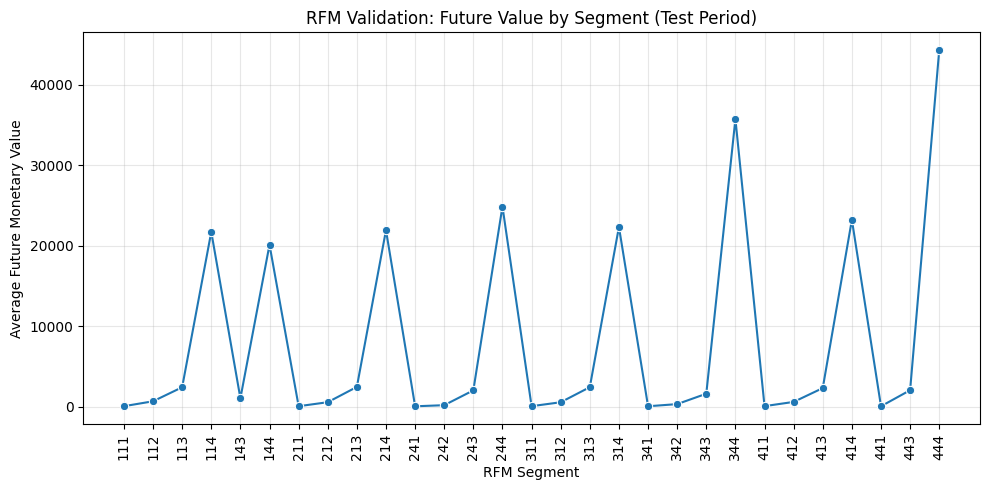

In [129]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=validation_stats.sort_values('RFMScore'),
    x='RFMScore',
    y='avg_future_value',
    marker='o'
)
plt.xticks(rotation=90)
plt.xlabel("RFM Segment")
plt.ylabel("Average Future Monetary Value")
plt.title("RFM Validation: Future Value by Segment (Test Period)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This graph help us answering the question **“Do customers classified as ‘better’ by RFM actually generate more value later?”**

* There is a clear upward pattern as we move toward segments with higher R, F, and M scores.

* Segments with low RFM scores (e.g., 111, 112, 113) show very low future value.

* Segments with high RFM scores (especially those ending in 4, like 344, 444) show much higher future monetary value.

* The highest-value segments are concentrated at the right end of the plot, where RFM scores are strongest.

* The sharp peaks are expected: high-value segments are fewer but much more valuable, so their averages stand out.

* The ordering of segments broadly follows the RFM logic: better past behavior = higher future value.

###5.1.4. RFM Interpretation and Campaign Strategy

Based on the recency dimension of the RFM model, we can associate different reviewer groups with distinct campaign strategies. This allows the segmentation results to be directly linked to potential actions, such as promotions, retention efforts, or reactivation campaigns.

In [130]:
# Assigning campagins
def assign_campaign(recency):
    if recency <= 180:
        return 'ACTIVE'
    elif recency <= 360:
        return 'AT RISK'
    else:
        return 'CHURNED'

In [131]:
# Copy of 'rfm_stats' and 'rfm_df'
rfm_campaigns = rfm_stats.copy()
rfm_df = rfm_df.copy()
rfm_df['campaign_type'] = rfm_df['Recency'].apply(assign_campaign)

In [132]:
#Create the campaign label in the data for the segments
rfm_campaigns['campaign_type'] = rfm_campaigns['avgRecency'].apply(assign_campaign)

In [133]:
# Create a table that shows how many RFM segments (RFMScore) fall into each campaign type (ACTIVE, AT RISK, CHURNED)
pd.crosstab(
    rfm_campaigns['campaign_type'],
    rfm_campaigns['RFMScore']
)


RFMScore,111,112,113,114,141,142,143,144,211,212,...,343,344,411,412,413,414,441,442,443,444
campaign_type,,,,,,,,,,,,,,,,,,,,,
ACTIVE,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,1,1,1,1
AT RISK,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
CHURNED,1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


/tmp/ipython-input-3511831904.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


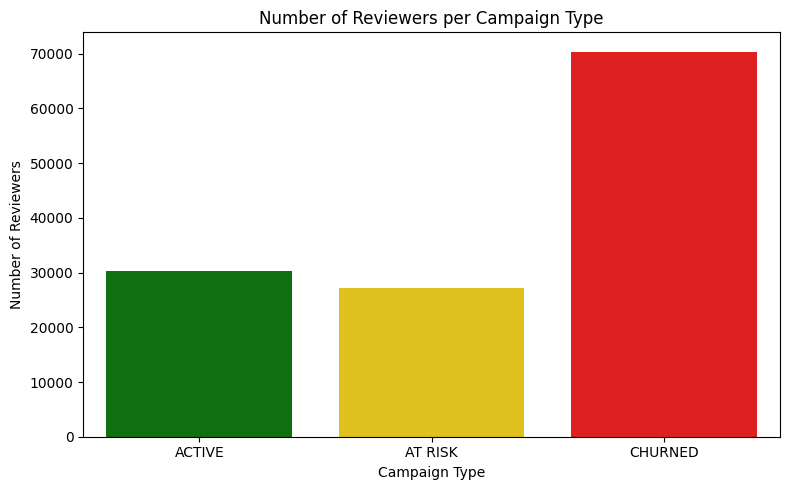

In [134]:
# Create the campaign label in the data for the reviewers
rfm_df['campaign_type'] = rfm_df['Recency'].apply(assign_campaign)

# Plot the distribution of reviewers across campaign types based on recency-based classification
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rfm_df,
    x='campaign_type',
    order=['ACTIVE', 'AT RISK', 'CHURNED'],
    palette={
        'ACTIVE': 'green',
        'AT RISK': 'gold',
        'CHURNED': 'red'
    }
)

plt.title('Number of Reviewers per Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Number of Reviewers')
plt.tight_layout()
plt.show()

* Most reviewers are classified as **CHURNED**. This indicates that a large share of reviewers have not interacted for a long time, suggesting disengagement

* **ACTIVE** reviewers form a smaller but still relevant group. These are the most recently engaged reviewers and represent the best opportunity for cross‑sell, up‑sell, and promotional campaigns

* **AT RISK** reviewers are the smallest group. This segment is important because timely retention actions could prevent them from becoming churned

* The imbalance highlights a retention challenge
The dominance of the **CHURNED** group suggests that improving reactivation and retention strategies should be a priority

* The campaign classification is actionable
By separating reviewers into **ACTIVE**, **AT RISK**, and **CHURNED**, the company can tailor different strategies instead of using a one‑size‑fits‑all approach

##5.2. Similarity Measures

In this section, we apply similarity measures to identify patterns of resemblance between entities in the dataset. By computing pairwise similarity based on selected features, we aim to understand which observations are more alike in terms of their behavioral and engagement profiles. Specifically, we aim to answer the questions:

**"Which attractions are similar in terms of visitor satisfaction, engagement, management behavior and visibility/popularity?"**

**"What attractions do we recommend to reviewers, similar to the ones they have already visited?"**

Therefore, rather than comparing reviewers (which proved unstable due to sparsity), we focus on attraction‑to‑attraction similarity.

###5.2.1. Unit of Analysis

The unit of analysis is the Reviewer–attraction interaction.

In [135]:
# Build a reviewer–attraction matrix
reviewer_attraction_matrix = data_df.pivot_table(
    index='reviewer',
    columns='tripadvisor_id',
    values='rating',
    aggfunc='mean'
).fillna(0)

In [136]:
reviewer_attraction_matrix

tripadvisor_id,10021146,10059931,10060270,10060294,10102362,10113758,10125587,10130233,10130271,10138634,...,9608966,9750479,9761837,9765683,9792122,9792343,9796506,9820608,9861448,9984750
reviewer,,,,,,,,,,,,,,,,,,,,,
"""BLUE""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#Boa Vista,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#daje,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Virginie S,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
-Carmel-Scarcella-,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
채연 탁,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
최윤환,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
필녕 이,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


* In the matrix rows are reviewers, columns are attractions and values represent how positively the reviewer evaluated the attraction.
* The zeros mean that the reviewer didn't review the corresponding attraction.

###5.2.2. Aggregate to attraction-level

To compute attraction similarity, we need to aggregated features that reflect
- Experience quality: average rating
- Visibility & popularity: review volume
- Reputation management: reply rate, fast reply rate
- Engagement: likes
- Reputational impact: monetary score
- Relative performance: normalized category ranking



In [137]:
# Aggregate features
attraction_features = (
    data_df
    .groupby('tripadvisor_id')
    .agg(
        avg_rating=('rating', 'mean'),
        avg_relative_ranking=('relative_ranking', 'mean'),
        pct_has_reply=('has_reply', 'mean'),
        pct_fast_reply=('fast_reply', 'mean'),
        pct_has_likes=('has_likes', 'mean'),
        avg_monetary=('monetary_score', 'mean'),
        review_volume=('num_reviews', 'mean')
    )
)

* These features capture how attractions behave and are perceived, not just how they are rated.

###5.2.3. Compute similarity

**Scaling**

In [138]:
# First we need to scale the features

scaler = StandardScaler()
attraction_features_scaled = pd.DataFrame(
    scaler.fit_transform(attraction_features),
    index=attraction_features.index,
    columns=attraction_features.columns
)

**Cosine distance**

In [139]:
# Compute attraction‑to‑attraction similarity
attraction_similarity = pd.DataFrame(
    1 - pairwise_distances(attraction_features_scaled, metric='cosine'),
    index=attraction_features_scaled.index,
    columns=attraction_features_scaled.index
)

* We used cosine distance to compute similarity as it focuses on relative patterns, not absolute magnitudes. It's also robust to scale differences after standardization and well‑suited for behavioral profile comparison.


**Recommendation System**

The recommendation system follows a clear and intuitive sequence:

1.	Randomly select an attraction and identify the most similar attractions to the one selected.
2.	Identify reviewers who visited the selected attraction and randomly select one.
3. Check attractions already visited by the target reviewer.
4.	Recommend to the selected reviewer similar attractions not yet visited by them.

This mimics a realistic scenario: “Visitors who enjoyed this attraction may also enjoy similar ones.”


####**1. Randomly select an attraction and identify the most similar attractions to the one selected**

In [140]:
# Pick randomly one attraction
example_id = attraction_similarity.sample(1).index[0]

# Get top 5 most similar attractions to example_id attraction
attraction_similarity.loc[example_id] \
    .sort_values(ascending=False) \
    .iloc[1:6]

,17584041
tripadvisor_id,
33099708,0.999999
23685045,0.999965
17572885,0.999943
9569099,0.999939
25553533,0.999888


####**2. Identify reviewers who visited the selected attraction and randomly select one**

In [141]:
# Check Reviewers who visited the selected attraction
reviewers_who_visited = (
    data_df
    .loc[data_df['tripadvisor_id'] == example_id, 'reviewer']
    .unique()
)

reviewers_who_visited

array(['Aridair Lucena Z', 'Daydream40826075188', 'Safari29061580670',
       'Rita', 'Daydream49114681985', 'Voyage788052', 'Sandra M',
       'LisbonHouse', 'Ruben A', 'Hannah D', 'Freedom15767483359',
       'Alisha W', 'Esther H', 'macau m', 'Jim C', 'Sightseer21037319866',
       'Virginia P', 'SandyFeinberg'], dtype=object)

In [142]:
# Pick one of those reviewers randomly
target_reviewer = np.random.choice(reviewers_who_visited)
target_reviewer

'Virginia P'

####**3. Check attractions already visited by the target reviewer**

In [143]:
# Get id of attractions already visited by the target reviewer
visited_by_reviewer = (
    data_df
    .loc[data_df['reviewer'] == target_reviewer, 'tripadvisor_id']
    .unique()
)
visited_by_reviewer

<StringArray>
['20951746', '17584041']
Length: 2, dtype: string

####**4. Recommend to the target reviewer similar attractions not yet visited by them**

In [144]:
# Get top 5 similar attractions to example_id, but exclude itself
similar_attractions = (
    attraction_similarity
    .loc[example_id]
    .sort_values(ascending=False)
    .iloc[1:6]   # keep top candidates
)

similar_attractions

,17584041
tripadvisor_id,
33099708,0.999999
23685045,0.999965
17572885,0.999943
9569099,0.999939
25553533,0.999888


In [145]:
# recommend attractions the reviewer has NOT visited
recommendations = (
    similar_attractions
    .drop(index=visited_by_reviewer, errors='ignore')
)

#####**Final Top 5 Recommendations**

In [146]:
#final recommendation
top_recommendations = recommendations.head(5)
top_recommendations

,17584041
tripadvisor_id,
33099708,0.999999
23685045,0.999965
17572885,0.999943
9569099,0.999939
25553533,0.999888


**Results**

Recommended attractions tend to:

⦁	Have similar quality levels

⦁	Belong to comparable experiential profiles

Some recommendations have:

⦁	High ratings but low review counts
Interpretation

⦁	This reflects genuine similarity in profile, not popularity bias

⦁	It highlights discoverability opportunities for less‑known attractions

##5.3. Market Basket Analysis

###5.3.1. Association Rule Mining: Rule Generation

In [147]:
# Create a unique identifier for each review so it can be treated as a "transaction"

data_df = data_df.reset_index(drop=True)
data_df['review_id'] = data_df.index

In [148]:
# Convert review features into a transaction-style format for association rules
association_long = []

binary_vars = [
    'has_likes',
    'has_reply',
    'fast_reply',
    'impact_rating',
    'mentions_price',
    'mentions_staff',
    'mentions_time',
    'mentions_crowd',
    'mentions_weather'
]

categorical_vars = [
    'seasonality',
    'visitType',
    'attractionCategory'
]



# Each row links a review to a binary attribute that is present
for var in binary_vars:
    temp = data_df.loc[data_df[var] == 1, ['review_id']].copy()
    temp['item'] = var
    association_long.append(temp)

# Add categorical attributes
# Each category value becomes its own item
for var in categorical_vars:
    for value in data_df[var].dropna().unique():
        temp = data_df.loc[data_df[var] == value, ['review_id']].copy()
        temp['item'] = f'{var}_{value}'
        association_long.append(temp)

# Combine all review–item relationships
association_long = pd.concat(association_long)


# Review–attribute relationship
# 'review_id' identifies the review and 'item' shows which characteristic is present in that review
association_long

,review_id,item
8,8,has_likes
24,24,has_likes
30,30,has_likes
40,40,has_likes
48,48,has_likes
...,...,...
139969,139969,attractionCategory_museums
113009,113009,attractionCategory_events
118091,118091,attractionCategory_events
118092,118092,attractionCategory_events


* If a review appears multiple times, it means it has multiple attributes (e.g., likes, replies, seasonality)

* This format prepares the data for association rule mining

In [149]:
# Create a pivot table  where each row represents a review and each column represents a review attribute
basket = pd.pivot_table(
    association_long,
    index='review_id',
    columns='item',
    aggfunc=lambda x: 1,   # A value of 1 indicates that the attribute is present in the review.
    fill_value=0
)

# This basket format is required to apply association rule mining
basket

item,attractionCategory_amusement parks,attractionCategory_boat tours & water sports,attractionCategory_classes & workshops,attractionCategory_events,attractionCategory_food & drink,attractionCategory_fun & games,attractionCategory_museums,attractionCategory_nature & parks,attractionCategory_nightlife,attractionCategory_outdoor activities,...,mentions_time,mentions_weather,seasonality_Off-Peak,seasonality_Peak,seasonality_Shoulder,visitType_Business,visitType_Couples,visitType_Family,visitType_Friends,visitType_Solo
review_id,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143603,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
143604,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
143605,0,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


* Each column is a review attribute (e.g. has_likes, fast_reply, mentions_price, seasonality_Peak)

* This creates a binary “basket” of attributes per review, similar to products in a shopping basket

* It allows us to discover which attributes tend to appear together in the same reviews

In [150]:
# Apply the Apriori algorithm to identify frequent combinations of review attributes
# Only itemsets that appear in at least 5% of the reviews are kept
frequent_itemsets = apriori(
    basket,
    min_support=0.05,
    use_colnames=True
)

# Sort itemsets by support (most frequent first)
frequent_itemsets_sorted = frequent_itemsets.sort_values(
    by='support',
    ascending=False
)

frequent_itemsets_sorted


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
4,0.483490,(attractionCategory_tours & activities)
9,0.435240,(mentions_staff)
13,0.390723,(seasonality_Shoulder)
7,0.343414,(has_reply)
11,0.322273,(seasonality_Off-Peak)
...,...,...
67,0.054468,"(visitType_Couples, seasonality_Off-Peak, attr..."
2,0.053813,(attractionCategory_outdoor activities)
77,0.053757,"(seasonality_Shoulder, visitType_Couples, ment..."
75,0.050255,"(seasonality_Shoulder, fast_reply, mentions_st..."


* The support value indicates the percentage of reviews in which that attribute appears

* For example: '(attractionCategory_tours & activities)' has a support of 0.48, meaning it appears in 48% of all reviews

* The most frequent attributes in the dataset are related to 'attractionCategory', 'mentions_staff', and 'seasonality', indicating that reviews are strongly influenced by staff experience, the type of attraction and the time of year

* More complex combinations of attributes appear less frequently but reveal meaningful patterns, such as the co‑occurrence of 'mentions_staff' and 'fast_reply' during the 'seasonality_Shoulder'. These combinations provide deeper insights into how review characteristics tend to cluster together



In [151]:
# Generate association rules from the frequent itemsets to identify which review attributes tend to appear together frequently

rules = association_rules(
    frequent_itemsets,
    metric="support",
    min_threshold=0.1
)

rules.sort_values(by='support', ascending=False)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(mentions_staff),(attractionCategory_tours & activities),0.435240,0.483490,0.256643,0.589658,1.219588,1.0,0.046209,1.258732,0.318810,0.387627,0.205550,0.560236
2,(attractionCategory_tours & activities),(mentions_staff),0.483490,0.435240,0.256643,0.530814,1.219588,1.0,0.046209,1.203701,0.348591,0.387627,0.169229,0.560236
15,(has_reply),(fast_reply),0.343414,0.243343,0.243343,0.708599,2.911937,1.0,0.159776,2.596622,1.000000,0.708599,0.614884,0.854300
14,(fast_reply),(has_reply),0.243343,0.343414,0.243343,1.000000,2.911937,1.0,0.159776,inf,0.867746,0.708599,1.000000,0.854300
9,(attractionCategory_tours & activities),(seasonality_Shoulder),0.483490,0.390723,0.184231,0.381044,0.975226,1.0,-0.004680,0.984361,-0.046877,0.267008,-0.015887,0.426278
8,(seasonality_Shoulder),(attractionCategory_tours & activities),0.390723,0.483490,0.184231,0.471512,0.975226,1.0,-0.004680,0.977335,-0.040025,0.267008,-0.023190,0.426278
29,(mentions_staff),(seasonality_Shoulder),0.435240,0.390723,0.175331,0.402838,1.031006,1.0,0.005273,1.020287,0.053251,0.269479,0.019884,0.425787
28,(seasonality_Shoulder),(mentions_staff),0.390723,0.435240,0.175331,0.448736,1.031006,1.0,0.005273,1.024480,0.049360,0.269479,0.023895,0.425787
18,(has_reply),(mentions_staff),0.343414,0.435240,0.160402,0.467080,1.073155,1.0,0.010934,1.059746,0.103822,0.259444,0.056378,0.417808
19,(mentions_staff),(has_reply),0.435240,0.343414,0.160402,0.368536,1.073155,1.0,0.010934,1.039784,0.120703,0.259444,0.038262,0.417808


* **Low lift** values (≈ 1): many rules have lift values close to 1. This means the attributes occur together mostly by chance and do not show a strong relationship

* Slightly **above‑1 lift** (weak positive association): some rules (e.g., visitType_Couples: attractionCategory_tours & activities) have lift just above 1. This indicates a small preference, but the effect is weak and not very impactful

* **High confidence but low support**: several rules show high confidence but low support. This means the relationship is reliable when it happens, but it applies to few reviews (e.g., mentions_staff, has_reply: fast_reply)

* **Moderate to high support** (common attributes): single attributes like 'attractionCategory_tours & activities', 'mentions_staff', and 'seasonality_Shoulder' have high support. These attributes appear frequently and describe general review behavior

* **Negative or near‑zero leverage**: rules with leverage close to zero (or negative) add little new information (e.g., seasonality_Off-Peak: mentions_staff). This means 'mentions_staff' appears almost just as often overall as it does in 'seasonality_Off-Peak' review, so they do not improve understanding

* Strongest and **most useful rules**: rules with both higher support and higher confidence are the most meaningful.
They represent patterns that are frequent and reliable, making them the best candidates for insights (e.g., attractionCategory_tours & activities: mentions_staff)

* **Seasonality** effects are weak: seasonality appears often but usually has lift close to 1. This means seasonality is common but does not strongly drive other attributes


###5.3.2. Visual Exploration of Association Rule Patterns

After identifying and filtering the association rules using, we used visualizations as a complementary step. The goal of these plots was to validate, compare, and better interpret the patterns already identified in the analysis



* **Support vs Confidence**

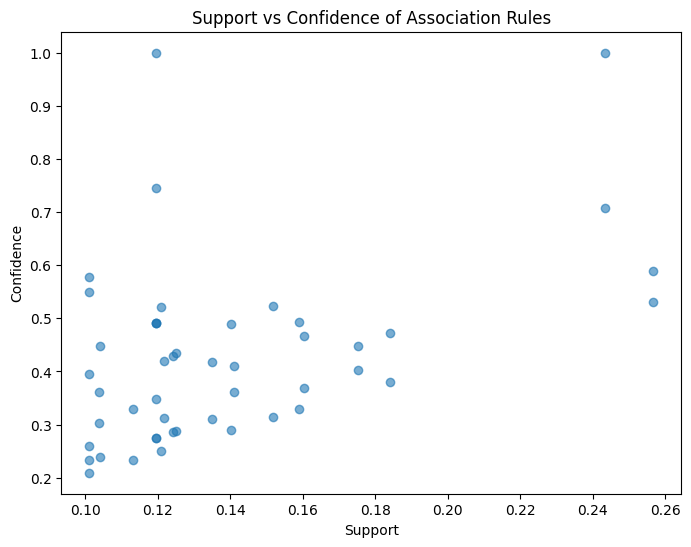

In [152]:
# Plot Support vs Confidence to understand rule frequency and reliability

plt.figure(figsize=(8, 6))
plt.scatter(rules['support'], rules['confidence'], alpha=0.6)

plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence of Association Rules')

plt.show()


* Most rules have low to medium support, these combinations do not appear in many reviews, so they describe specific situations, not general behavior

* Some rules have high confidence, when these patterns appear, they are very consistent (one attribute usually comes with the other)

* The most useful rules combine higher support and higher confidence, making them the most meaningful insights

**Lift Distribution**

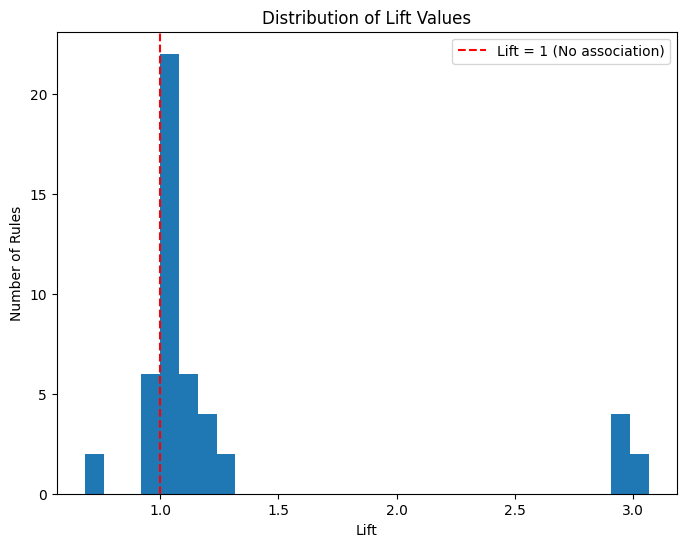

In [153]:
# Plot the distribution of Lift values to evaluate rule usefulness

plt.figure(figsize=(8, 6))
plt.hist(rules['lift'], bins=30)

plt.axvline(x=1, color='red', linestyle='--', label='Lift = 1 (No association)')
plt.xlabel('Lift')
plt.ylabel('Number of Rules')
plt.title('Distribution of Lift Values')
plt.legend()

plt.show()

* Most rules have lift close to 1, this means many attribute combinations occur together by chance and do not show a strong relationship. These rules do not provide very useful insights

* Only a few rules have high lift (> 1), these rules show meaningful associations, where one attribute truly increases the likelihood of the other

* Very high lift rules are rare, strong relationships exist, but they apply to specific situations

* Focus should be on rules with lift above 1 since they represent the most informative and actionable patterns

**Support vs Lift**

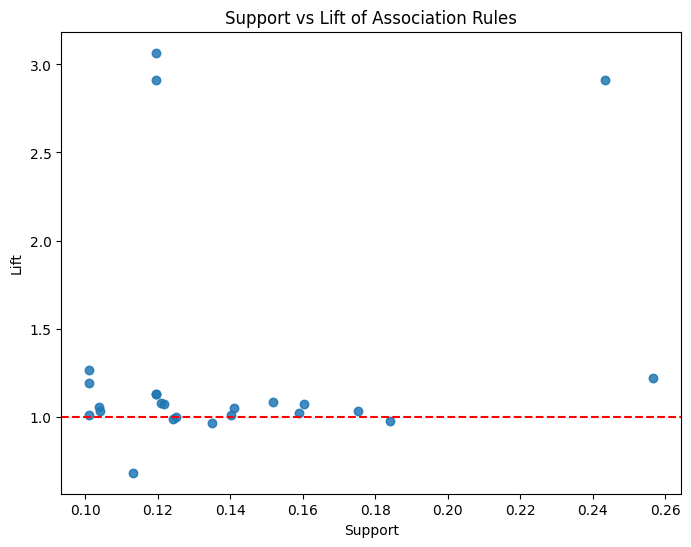

In [154]:
# Plot Support vs Lift to compare frequency and strength of rules

plt.figure(figsize=(8, 6))
plt.scatter(rules['support'], rules['lift'], alpha=0.6)

plt.axhline(y=1, color='red', linestyle='--')
plt.xlabel('Support')
plt.ylabel('Lift')
plt.title('Support vs Lift of Association Rules')

plt.show()

* Most rules lie close to lift = 1, indicating weak or no meaningful association

* The majority of rules have support between 0.10 and 0.18, showing that most patterns apply to a moderate portion of the reviews, rather than being extremely frequent or very rare.

* A small number of rules show high lift values (close to 3). Although these rules have lower support, they indicate strong associations: when the antecedent occurs, the consequent is much more likely than expected

* One rule combines relatively high support (around 0.26) with lift slightly above 1. This suggests a frequent pattern with a mild positive association, making it more generally applicable but less strong in terms of dependency because of the low lift value that presents.


**Overall conclusion on visualizations:**

These visualizations confirm the patterns identified in the previous analysis. In this way, the visual analysis reinforces our earlier observations and provides a clearer understanding of the main patterns in the data


###5.3.3. Visualization of Association Rule Structures and Relationships

**Bubble plot**

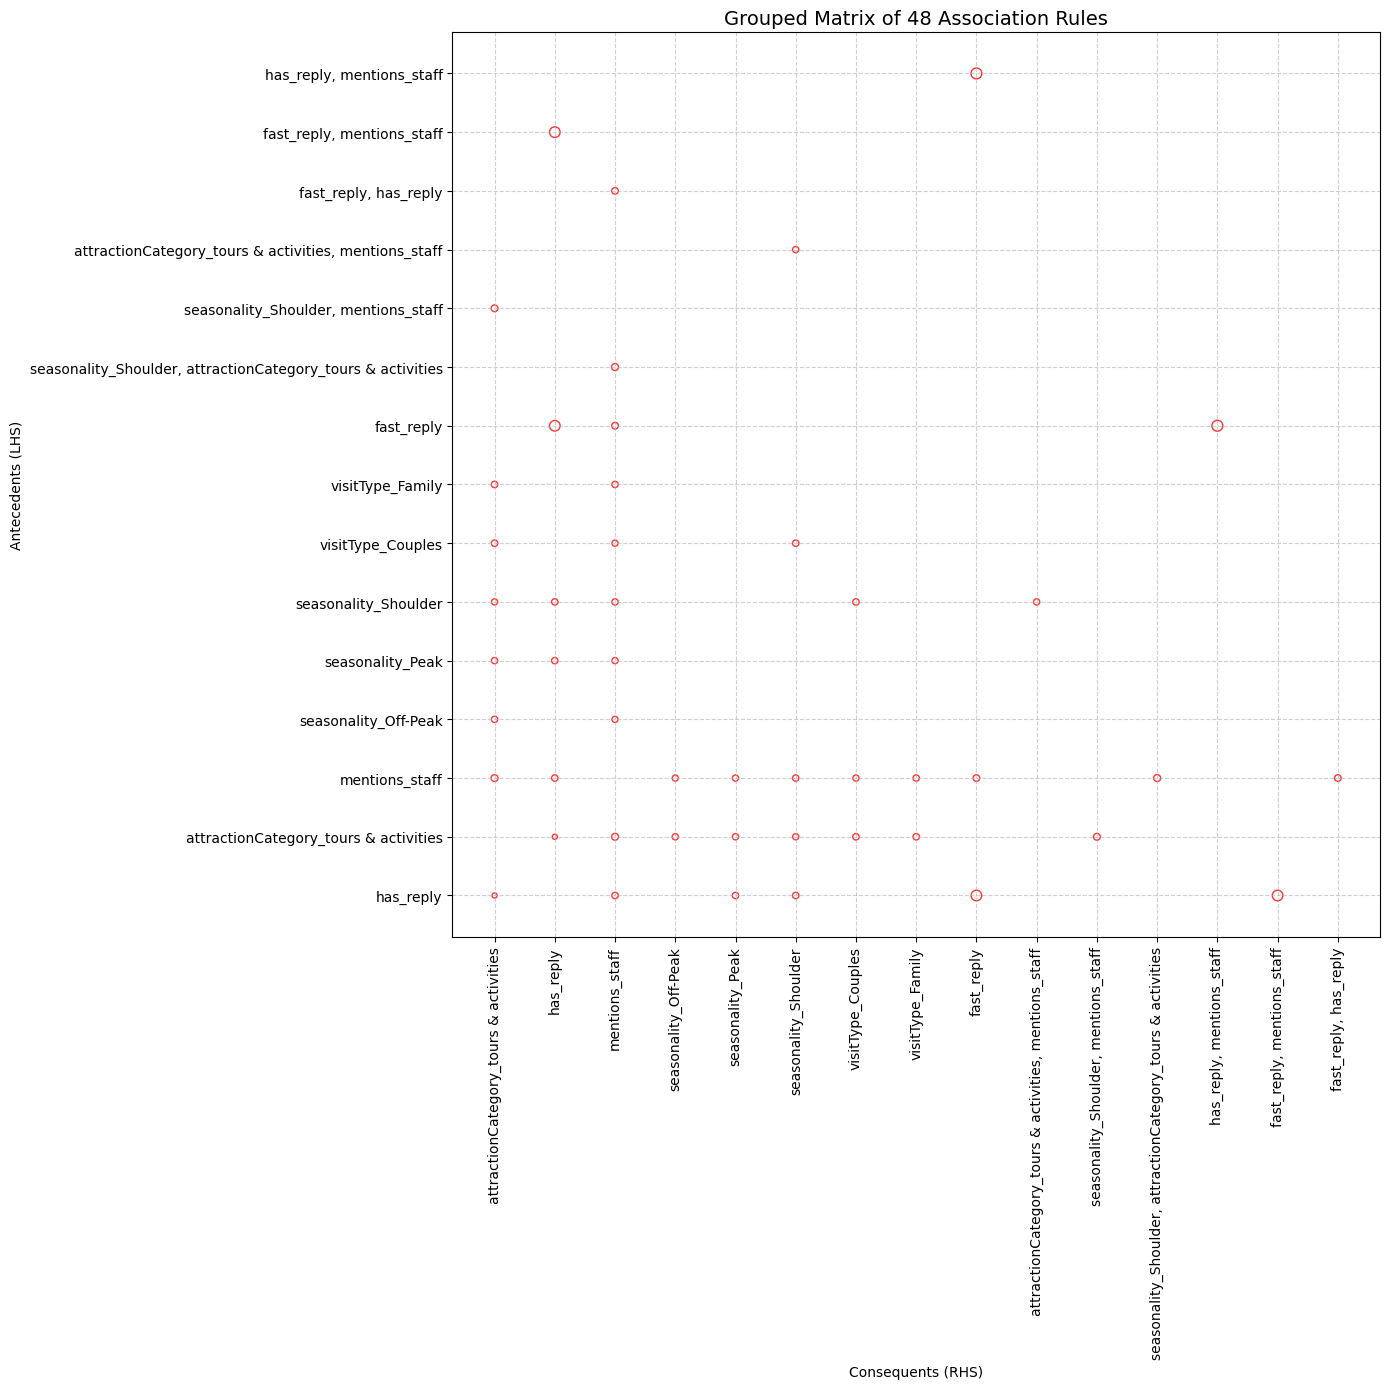

In [155]:
# Make a copy to avoid modifying the original rules dataframe
rules_plot = rules.copy()

# Convert frozensets into readable strings
rules_plot['antecedents_str'] = rules_plot['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_plot['consequents_str'] = rules_plot['consequents'].apply(lambda x: ', '.join(list(x)))

# Create the bubble plot
plt.figure(figsize=(14, 14))

plt.scatter(
    x=rules_plot['consequents_str'],
    y=rules_plot['antecedents_str'],
    s=rules_plot['lift'] * 20,   # Bubble size proportional to lift
    edgecolors='red',
    facecolors='white',
    alpha=0.8
)

# Plot formatting
n_rules = rules_plot.shape[0]
plt.title(f"Grouped Matrix of {n_rules} Association Rules", fontsize=14)
plt.xlabel("Consequents (RHS)")
plt.ylabel("Antecedents (LHS)")
plt.grid(linestyle="--", alpha=0.6)
plt.xticks(rotation=90)

# Antecedents and consequents are shown as a matrix, and bubble size represents lift
plt.tight_layout()
plt.show()


* **Concentration around key variables:**
Most rules involve a small set of recurring items, particularly mentions_staff, has_reply, fast_reply, and attractionCategory_tours & activities. This indicates these features are central in the association structure.

* **Moderate rule strength overall:**
The majority of bubbles are relatively small to medium in size, showing that most rules have moderate lift rather than very strong dependency.

**Network graph**

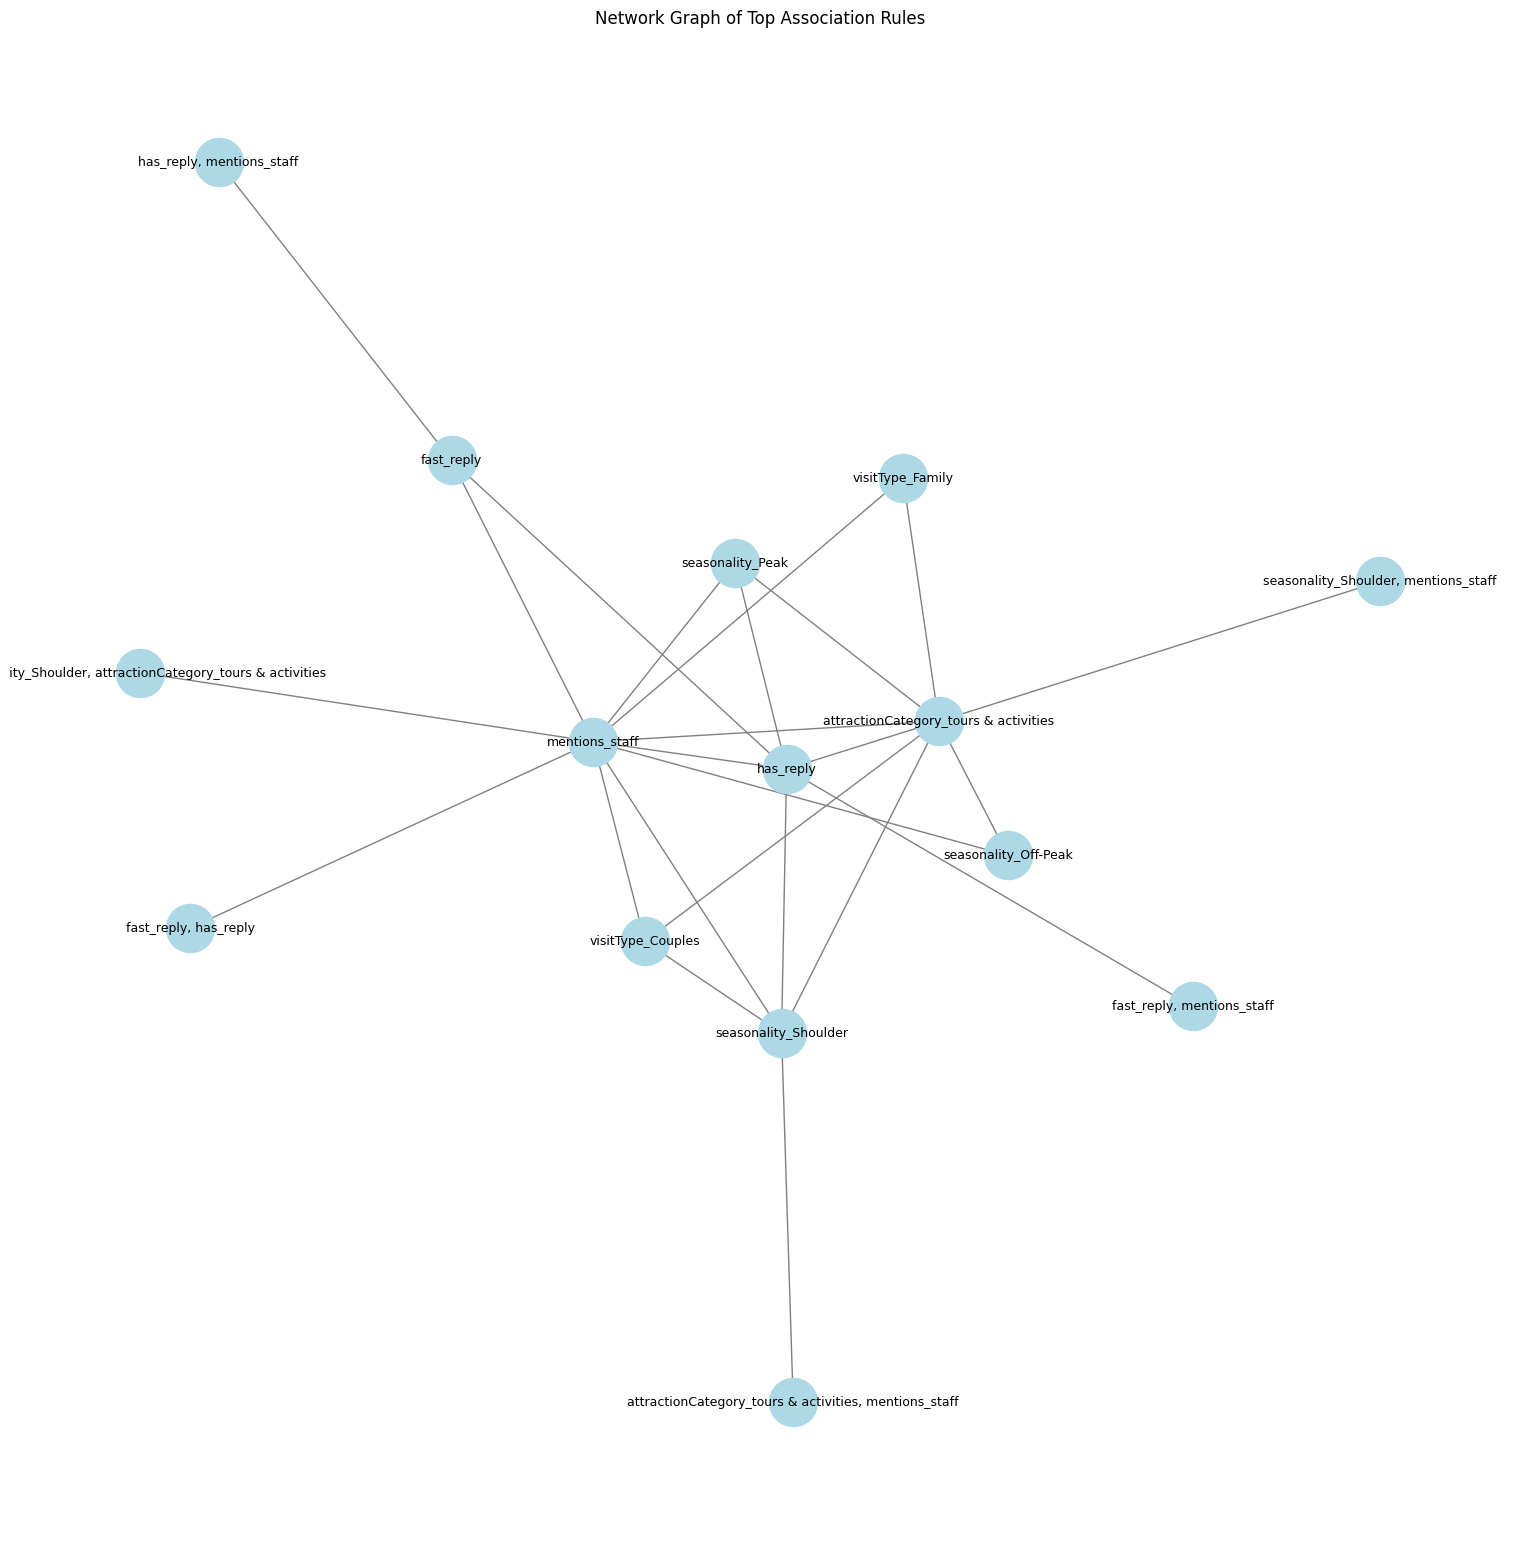

In [156]:
# Select the rules to plot (e.g., highest confidence rules)
rulesToPlot = rules.sort_values(by='confidence', ascending=False).copy()

# Convert frozensets to readable strings
rulesToPlot['LHS'] = rulesToPlot['antecedents'].apply(lambda x: ', '.join(list(x)))
rulesToPlot['RHS'] = rulesToPlot['consequents'].apply(lambda x: ', '.join(list(x)))

# Remove duplicate rules that appear reversed (A → B and B → A)
rulesToPlot['sorted_pair'] = rulesToPlot.apply(
    lambda row: str(sorted([row['LHS'], row['RHS']])), axis=1
)
rulesToPlot = rulesToPlot.drop_duplicates(subset='sorted_pair')

# Keep only the top 30 rules
rulesToPlot = rulesToPlot.head(30)

# Build the network graph
G = nx.from_pandas_edgelist(
    rulesToPlot,
    source='LHS',
    target='RHS'
)

# Plot
plt.figure(figsize=(15, 15))
np.random.seed(42)
pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    node_color="lightblue",
    edge_color="gray",
    font_size=9
)

plt.title("Network Graph of Top Association Rules")
plt.axis('off')
plt.show()


* **Central hubs dominate the network:**
mentions_staff, attractionCategory_tours & activities and has_reply act as hubs with many connections, highlighting their high relevance across multiple rules.

* **Contextual features play a secondary role:**
Variables such as seasonality and visitType connect mainly through the central hubs, suggesting they influence reviews indirectly.

* **Tours & activities link multiple dimensions:**
attractionCategory_tours & activities connects with visit type, seasonality, and staff mentions, positioning it as a bridge between experience context and service quality.

* **No isolated clusters:** The network is fairly connected, implying that review attributes are interdependent rather than independent signals.

# 6. Evaluation

The Evaluation phase assesses whether the analytical results produced in the previous steps are meaningful, reliable, and aligned with the project objectives. Rather than focusing on predictive accuracy, this phase emphasizes validation through hypothesis testing, robustness checks, interpretability, and business relevance. The goal is to ensure that insights derived from text mining, RFM analysis, similarity measures and market basket analysis can support informed decision‑making before moving to deployment.

## 6.1. Hypothesis Testing

The hypotheses to be develop are based in what we already built and visualized previously. By making statistical evaluations these will become defensible academically.

###6.1.1. H1 - Sentiment as an Early‑Warning Signal

**Research question:** Do changes in sentiment precede changes in numerical ratings?


* H₀ (null): There is no monotonic association between average sentiment in month t and average rating in month t+1.

* H₁ (alternative): Higher average sentiment in month t is associated with higher average ratings in month t+1.

**Test:**

* Spearman Rank Correlation

**Why:**

* If sentiment deteriorates earlier than ratings, it can be used as an early‑warning indicator, allowing intervention before visible rating damage occurs.

####Step 1. Monthly variables and aggregation

In [157]:
# Create year-month variable
data_df['year_month'] = data_df['visit_date'].dt.to_period('M')

# Aggregate monthly averages
monthly_df = (
    data_df
    .groupby('year_month')
    .agg(
        avg_sentiment=('sentiment_score', 'mean'),
        avg_rating=('rating', 'mean'),
        n_reviews=('rating', 'count')
    )
    .reset_index()
)

# Create lead variable: next month's average rating
monthly_df['avg_rating_lead'] = monthly_df['avg_rating'].shift(-1)

# Drop last month (no lead value)
monthly_df = monthly_df.dropna(subset=['avg_rating_lead'])


####Step 2. Spearman Correlation

In [158]:
# Spearman correlation

corr_h1, pval_h1 = spearmanr(
    monthly_df['avg_sentiment'],
    monthly_df['avg_rating_lead']
)

print(f"H1 Spearman correlation: {corr_h1:.3f}")
print(f"H1 p-value: {pval_h1:.4e}")


H1 Spearman correlation: 0.735
H1 p-value: 1.3606e-08


**Results**
* Spearman ρ: 0.735

* p‑value: 1.36 × 10⁻⁸

**Decision Rule**
* If p < 0.05 → reject H₀

* If p ≥ 0.05 → fail to reject H₀

Given the extremely small p‑value, the null hypothesis is rejected.

**Interpretation**

There is a strong, positive, and statistically significant association between average sentiment in month t and average ratings in month t+1. This provides evidence that sentiment shifts precede rating changes, supporting the hypothesis that sentiment acts as an early‑warning indicator of future satisfaction.

###6.1.2. H2 - Impact of Crowding on Satisfaction

**Research question:** Do attractions with frequent crowding complaints receive lower ratings during peak season?

* H₀: There is no difference in visitor ratings between reviews mentioning crowding and reviews not mentioning crowding during peak season.

* H₁: Reviews mentioning crowding during peak season are associated with lower visitor ratings compared to reviews without crowding complaints.

**Test:**

* Mann–Whitney U test

**Why this matters:**

* Visitor ratings are measured on an ordinal scale and do not satisfy normality assumptions. The Mann–Whitney U test is therefore appropriate to compare rating distributions between two independent groups (Reviews mentioning crowding, Reviews not mentioning crowding)
* This test evaluates whether one group tends to receive systematically lower ratings than the other.

####Step 1. Create rating vs crowding indicator

In [159]:
# Filter Peak Season only
peak_df = data_df[data_df['seasonality'] == 'Peak']

# Split groups
ratings_crowd = peak_df.loc[peak_df['mentions_crowd'] == True, 'rating']
ratings_no_crowd = peak_df.loc[peak_df['mentions_crowd'] == False, 'rating']

####Step 2. Mann–Whitney U test

In [160]:
# Mann–Whitney U test
u_stat, pval_h2 = mannwhitneyu(
    ratings_crowd,
    ratings_no_crowd,
    alternative='two-sided'
)

print(f"H2 U-statistic: {u_stat:.0f}")
print(f"H2 p-value: {pval_h2:.4e}")

H2 U-statistic: 9168164
H2 p-value: 7.8345e-84


**Test Results**
* U‑statistic: 9,168,164

* p‑value: 7.8345 × 10⁻⁸⁴

**Decision Rule**
* If p < 0.05 → reject H₀

Given the extremely small p‑value, the null hypothesis is rejected.


**Interpretation**
* The results provide strong statistical evidence that reviews mentioning crowding during peak season are associated with significantly lower ratings. This indicates that overcrowding has a measurable negative impact on visitor satisfaction.

##6.2. Evaluation Summary & Readiness

###6.2.1. Summary of Analytical Components Evaluated

Across the CRISP‑DM methodology, multiple complementary analytical approaches were developed and evaluated:

* **Exploratory Data Analysis (EDA)** revealed strong heterogeneity across attractions in terms of ratings, review volumes, seasonality, and visitor behavior, highlighting the limitations of relying on aggregate metrics alone.

* **Text Mining and Sentiment Analysis** transformed unstructured reviews into interpretable sentiment scores and thematic signals, enabling meaningful insight into drivers of satisfaction and dissatisfaction.

* **RFM Analysis** characterized reviewer engagement patterns, confirming that users differ substantially in recency, frequency, and contribution intensity.

* **Similarity Modeling** identified attractions with comparable experience profiles, forming the basis for recommendation and benchmarking use cases.

* **Market Basket Analysis** uncovered co‑visitation patterns between attractions, supporting cross‑promotion.

###6.2.2. Hypothesis Testing Outcomes

The hypothesis tests conducted in provide statistical validation for the most critical modeling assumptions:

**H1 — Sentiment as an Early‑Warning Signal**
* A strong and statistically significant Spearman correlation between sentiment scores and numerical ratings (ρ = 0.735, p ≪ 0.001) confirms that textual sentiment captures meaningful variation in visitor satisfaction. This validates sentiment analysis as a reliable early‑warning indicator, capable of detecting shifts in visitor experience before they are fully reflected in ratings.

**H2 — Impact of Crowding on Satisfaction**
* The Mann–Whitney U test reveals a highly significant difference in ratings between reviews mentioning crowding and those that do not (p ≪ 0.001). This result confirms that crowding complaints are systematically associated with lower satisfaction, particularly during peak periods, reinforcing the operational relevance of topic‑level text signals.

###6.2.3. Sanity Checks and Robustness

* Consistency between sentiment distributions and rating levels

* Stability of patterns across attractions and time periods

* Extremely small p‑values interpreted correctly as evidence of strong effects rather than computational errors, given the large sample size

* Coherence between qualitative review content and quantitative metrics

No contradictions were observed between different analytical methods (ratings, sentiment, RFM, similarity, and market basket analysis), increasing confidence in the findings.

###6.2.4. Interpretability and Stakeholder Relevance

A key strength of the evaluation results is their interpretability for non‑technical stakeholders:

* Sentiment and topic signals can be directly mapped to operational levers (e.g., crowd management, service quality).

* RFM profiles enable differentiation between casual and highly engaged reviewers.

* Similarity and market basket outputs support recommendation, bundling, and marketing use cases without requiring complex models.

All evaluated components produce outputs that can be explained visually and conceptually, facilitating adoption by LTA's managers and marketing teams.



#7. Conclusions

This project demonstrates how large‑scale online reviews can be transformed into actionable intelligence for destination management. By combining text mining, sentiment analysis, behavioral segmentation (RFM), similarity analysis, and statistical validation, we move beyond aggregate ratings to uncover why visitors are satisfied or dissatisfied and where intervention is most effective.

The results show a strong and statistically significant alignment between textual sentiment and numerical ratings, validating sentiment analysis as a reliable early‑warning signal. Additionally, attractions associated with frequent crowding complaints experience significantly lower satisfaction during peak periods, highlighting clear opportunities for demand management and operational improvements.

Segmentation and similarity analyses further confirm that visitor behavior and attraction profiles are meaningfully differentiated, supporting the use of targeted strategies rather than one‑size‑fits‑all approaches. Importantly, all key insights were validated through appropriate non‑parametric hypothesis testing, ensuring robustness and academic credibility.

Overall, the analytical framework developed is coherent, validated, and ready for deployment. It enables Turismo de Lisboa to proactively monitor visitor experience, identify emerging issues early, and design more precise, data‑driven marketing and operational responses.